<a href="https://colab.research.google.com/github/diegozuzu/mvpdiegozuzu/blob/main/Diego_Zuzu_Machine_Learning_%26_Analytics_Banknote_Authentication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MVP: *Machine Learning & Analytics*
**Autor:** _DIEGO HENRIQUE PAZ ZUZU_  

**Data:** 28/09/2025

**Matrícula:** 4052025000149

**Dataset:** [Banknote Authentication](https://raw.githubusercontent.com/diegozuzu/mvpdiegozuzu/refs/heads/main/data_banknote_authentication.txt)

## 1. Escopo, objetivo e definição do problema

**CONTEXTO DO PROBLEMA:**

- Detecção de autenticidade de cédulas bancárias (notas de dinheiro).


**OBJETIVO:**

- Classificar cédulas como autênticas (classe 0) ou falsificadas (classe 1) com base em características extraídas de imagens digitalizadas. Trata-se de um problema de detecção de fraude em cédulas físicas.


**TIPO DE TAREFA:**

- Classificação binária supervisionada, pois o dataset inclui um rótulo categórico (0 ou 1) indicando a classe de cada cédula. O modelo deve aprender padrões nos atributos numéricos para distinguir entre as duas categorias.


**ÁREA DE APLICAÇÃO:**

- Dados tabulares com atributos numéricos derivados de processamento de imagens (transformada wavelet). Embora os dados tenham origem em imagens, a análise é realizada em formato estruturado (tabela), sem manipulação direta de pixels ou técnicas de visão computacional no notebook.


**VALOR PARA O NEGÓCIO/USUÁRIO:**

- Automação de processos: Reduz a dependência de verificação manual de cédulas, agilizando operações em bancos, caixas eletrônicos ou comércio.
- Segurança financeira: Minimiza riscos de perdas devido à circulação de cédulas falsas.
- Custo-efetividade: Sistemas automatizados podem operar em escala com maior precisão e menor custo comparado à inspeção humana.
- Aplicações práticas: Integrável a equipamentos de contagem ou verificação de cédulas, como em máquinas de venda automática ou sistemas bancários.


## 2. Reprodutibilidade e ambiente

**OBJETIVO PRINCIPAL**

- Preparar o ambiente para criar um sistema que identifica automaticamente cédulas falsas usando inteligência artificial.

**O QUE O CÓDIGO FAZ:**

**IMPORTA FERRAMENTAS NECESSÁRIAS**

- Kit de análise de dados (NumPy, Pandas)
- Kit de gráficos (Matplotlib, Seaborn)
- Kit de machine learning (scikit-learn)

**GARANTE REPRODUCIBILIDADE**

- Configura "semente aleatória" (SEED = 42)
- Garante que resultados sejam sempre os mesmos

**CONFIGURA O PROBLEMA**

- O que analisar: Cédulas bancárias
- Objetivo: Separar autênticas (0) vs falsas (1)
- Características usadas: 4 medidas técnicas das cédulas

**FERRAMENTAS ESPECÍFICAS IMPORTADAS:**

- Modelos de IA: Regressão Logística, Random Forest, SVM, etc.
- Métricas de avaliação: Precisão, Recall, AUC-ROC
- Otimização: Busca automática de melhores configurações

**CONFIGURA VISUAL**

- Define cores e estilo dos gráficos (azul/verde)
- Padroniza visualizações para melhor entendimento

In [28]:
# === Reprodutibilidade para Banknote Authentication ===

# Bibliotecas para manipulação de dados e visualização
import os, random, time, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para pré-processamento e pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Bibliotecas para modelos de classificação
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold

# Bibliotecas para avaliação de modelos
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)

# Bibliotecas para otimização de hiperparâmetros
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform

# Configuração de semente para reprodutibilidade
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Configuração de estilo para visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

# Informações do ambiente
print("=== Ambiente de Análise - Banknote Authentication ===")
print("Python:", sys.version.split()[0])
print("Seed global para reprodutibilidade:", SEED)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print(f"Dataset: Banknote Authentication (UCI)")
print(f"Problema: Classificação binária - Cédulas autênticas vs. falsificadas")
print(f"Atributos: variance, skewness, curtosis, entropy")
print(f"Classe alvo: 0 (autêntica), 1 (falsificada)")
print("=" * 60)

=== Ambiente de Análise - Banknote Authentication ===
Python: 3.12.11
Seed global para reprodutibilidade: 42
NumPy: 2.0.2
Pandas: 2.2.2
Dataset: Banknote Authentication (UCI)
Problema: Classificação binária - Cédulas autênticas vs. falsificadas
Atributos: variance, skewness, curtosis, entropy
Classe alvo: 0 (autêntica), 1 (falsificada)



### 2.1 Dependências

**OBJETIVO PRINCIPAL**

- Preparar ferramentas extras para tornar a análise de cédulas falsas mais poderosa e completa.

**O QUE O CÓDIGO OFERECE:**

**ANÁLISE MAIS DETALHADA**

- pandas-profiling: Gera relatório automático dos dados
- statsmodels: Análise estatística profissional

**VISUALIZAÇÕES MELHORES**

- plotly: Gráficos interativos (zoom, detalhes)

**MODELOS MAIS AVANÇADOS**

- xgboost e lightgbm: Modelos de elite
- imbalanced-learn: Corrige desbalanceamento (55% vs 45%)

In [29]:

# Para análise exploratória avançada:
# !pip install -q pandas-profiling ydata-profiling

# Para visualizações interativas:
# !pip install -q plotly

# Para modelos ensemble avançados:
# !pip install -q xgboost lightgbm

# Para tratamento de desbalanceamento:
# !pip install -q imbalanced-learn

# Para análise estatística mais aprofundada:
# !pip install -q statsmodels

print("✅ Dependências configuradas para análise de detecção de cédulas falsas")
print("📊 Dataset: Banknote Authentication (1372 amostras, 4 atributos)")
print("🎯 Objetivo: Classificação binária - Autêntica (0) vs Falsificada (1)")


✅ Dependências configuradas para análise de detecção de cédulas falsas
📊 Dataset: Banknote Authentication (1372 amostras, 4 atributos)
🎯 Objetivo: Classificação binária - Autêntica (0) vs Falsificada (1)


### 2.2 Funções python

**OBJETIVO PRINCIPAL**

- Desenvolver um framework modular de funções utilitárias para padronizar e automatizar a avaliação de modelos de classificação binária aplicados à detecção de autenticidade de cédulas.

**AS 5 FERRAMENTAS CRIADAS:**

1. **AVALIADOR AUTOMÁTICO**

evaluate_banknote_classification()

- Calcula 8 métricas de uma vez
- Foca em detecção de fraudes (falsos positivos/negativos)
- Gera relatório completo automaticamente

2. **MATRIZ DE CONFUSÃO VISUAL**

plot_banknote_confusion_matrix()

- Mostra erros de classificação em gráfico
- Labels em português (Autêntica/Falsificada)
- Fácil de entender onde o modelo erra

3. **CURVA ROC PROFISSIONAL**

plot_roc_curve_banknote()

- Avalia qualidade das probabilidades
- Mostra performance em todos os thresholds
- Inclui área sob a curva (AUC)

4. **COMPARADOR DE MODELOS**

compare_banknote_models()

- Ranking automático dos melhores modelos
- Tabela colorida com destaques
- Ordena por performance (AUC-ROC)

5. **ANALISADOR DE IMPORTÂNCIA**

feature_importance_banknote()

- Identifica quais características mais importantes
- Gráfico de barras das features
- Entende o que o modelo "presta atenção"

**VANTAGENS:**

- Padronização: Todos avaliam do mesmo jeito
- Eficiência: Uma linha de código vs horas programando
- Visualização: Gráficos prontos e profissionais
- Comparação: Decisão fácil sobre qual modelo usar

In [30]:
# Funções utilitárias para facilitar a análise de classificação binária de cédulas

def evaluate_banknote_classification(y_true, y_pred, proba=None, model_name=""):
    """
    Avalia modelo de classificação para detecção de cédulas falsas
    Retorna métricas relevantes para problema binário
    """
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")

    # AUC-ROC apenas se probabilidades estiverem disponíveis
    if proba is not None and proba.shape[1] == 2:
        auc = roc_auc_score(y_true, proba[:, 1])
    else:
        auc = np.nan

    # Métricas específicas para detecção de fraudes
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Taxa de verdadeiros negativos

    results = {
        "accuracy": round(acc, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "f1_weighted": round(f1w, 4),
        "roc_auc": round(auc, 4) if not np.isnan(auc) else np.nan,
        "specificity": round(specificity, 4),
        "false_positive_rate": round(fp / (fp + tn), 4) if (fp + tn) > 0 else 0
    }

    if model_name:
        results["model"] = model_name

    return results

def plot_banknote_confusion_matrix(y_true, y_pred, model_name=""):
    """
    Plota matriz de confusão para classificação de cédulas
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Autêntica', 'Falsificada'],
                yticklabels=['Autêntica', 'Falsificada'])
    plt.xlabel('Predito')
    plt.ylabel('Real')
    title = f'Matriz de Confusão - {model_name}' if model_name else 'Matriz de Confusão'
    plt.title(title)
    plt.show()

def plot_roc_curve_banknote(y_true, proba, model_name=""):
    """
    Plota curva ROC para modelos de classificação binária
    """
    if proba is not None and proba.shape[1] == 2:
        fpr, tpr, _ = roc_curve(y_true, proba[:, 1])
        auc_score = roc_auc_score(y_true, proba[:, 1])

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {auc_score:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        title = f'Curva ROC - {model_name}' if model_name else 'Curva ROC'
        plt.title(title)
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

def compare_banknote_models(results_dict):
    """
    Compara resultados de múltiplos modelos em formato tabular
    """
    comparison_df = pd.DataFrame(results_dict).T
    comparison_df = comparison_df.sort_values('roc_auc', ascending=False)

    # Estilizar a tabela para melhor visualização
    styled_df = comparison_df.style\
        .background_gradient(subset=['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'],
                           cmap='YlOrBr')\
        .format("{:.4f}", subset=['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'])

    return styled_df

def feature_importance_banknote(model, feature_names):
    """
    Analisa importância das features para modelos que suportam essa funcionalidade
    """
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feature_imp_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importance
        }).sort_values('importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(data=feature_imp_df, x='importance', y='feature', palette='viridis')
        plt.title('Importância das Features para Detecção de Cédulas Falsas')
        plt.xlabel('Importância')
        plt.tight_layout()
        plt.show()

        return feature_imp_df
    else:
        print("Modelo não suporta análise de importância de features")
        return None

print("✅ Funções utilitárias para Banknote Authentication carregadas")
print("📊 Funções disponíveis:")
print("   - evaluate_banknote_classification() - Avaliação completa do modelo")
print("   - plot_banknote_confusion_matrix() - Visualização matriz de confusão")
print("   - plot_roc_curve_banknote() - Curva ROC")
print("   - compare_banknote_models() - Comparação entre modelos")
print("   - feature_importance_banknote() - Análise de importância das features")

✅ Funções utilitárias para Banknote Authentication carregadas
📊 Funções disponíveis:
   - evaluate_banknote_classification() - Avaliação completa do modelo
   - plot_banknote_confusion_matrix() - Visualização matriz de confusão
   - plot_roc_curve_banknote() - Curva ROC
   - compare_banknote_models() - Comparação entre modelos
   - feature_importance_banknote() - Análise de importância das features



## 3. Dados: carga, entendimento e qualidade

**ORIGEM DOS DADOS**

- O dataset Banknote Authentication foi criado a partir de imagens de cédulas genuínas e falsificadas para autenticação automática. As amostras foram extraídas de imagens que foram digitalizadas de cédulas genuínas e falsificadas. Para a digitalização, foi usado um scanner comum com resolução de 300dpi. As imagens das cédulas foram subsequentemente processadas com transformada wavelet.

**DICIONÁRIO DE VARIÁVEIS**

O dataset contém as seguintes variáveis:

- variance (float): Variância da transformada wavelet da imagem

- skewness (float): Assimetria da transformada wavelet da imagem

- curtosis (float): Curtose da transformada wavelet da imagem

- entropy (float): Entropia da imagem

- class (int): Classe da cédula (0 = autêntica, 1 = falsificada)

**LICENÇA E ASPECTOS ÉTICOS**

- **Licença:** O dataset está disponível publicamente no UCI Repository para fins de pesquisa e educação.

- **Ética:** Os dados foram anonimizados e não contêm informações pessoais identificáveis.

- **Uso:** Apropriado para classificação binária e aprendizado de máquina educacional

**QUALIDADE DOS DADOS**

- O dataset é conhecido por ser bem estruturado, sem valores faltantes e com boa separabilidade entre classes, tornando-o adequado para experimentos de classificação.

In [31]:
# === Carga dos dados ===

try:
    # Carregar dataset diretamente do GitHub
    url = "https://raw.githubusercontent.com/diegozuzu/mvpdiegozuzu/refs/heads/main/data_banknote_authentication.txt"
    column_names = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
    df = pd.read_csv(url, header=None, names=column_names)

    print("✅ Dataset carregado com sucesso do GitHub")
    print(f"📊 Fonte: {url}")

except Exception as e:
    print(f"❌ Erro ao carregar do GitHub: {e}")

    # Fallback: Dataset de exemplo para continuidade da análise
    print("⚠️  Carregando dataset de exemplo para demonstração")
    np.random.seed(SEED)
    n_samples = 1372  # Mesmo tamanho do dataset real

    df = pd.DataFrame({
        "variance": np.random.normal(0, 3, size=n_samples),
        "skewness": np.random.normal(0, 6, size=n_samples),
        "curtosis": np.random.normal(0, 4, size=n_samples),
        "entropy": np.random.normal(-1, 2, size=n_samples),
        "class": np.random.choice([0, 1], size=n_samples, p=[0.555, 0.445])
    })

# === Informações básicas do dataset ===
print("\n" + "="*60)
print("📊 INFORMAÇÕES DO DATASET - BANKNOTE AUTHENTICATION")
print("="*60)
print(f"📈 Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"🎯 Variável alvo: 'class' (0 = autêntica, 1 = falsificada)")
print(f"🔢 Atributos preditores: 4 características de imagem")
print(f"📅 Tipo de dados: Dados estáticos/históricos")
print(f"🌐 Origem: Processamento de imagens de cédulas bancárias")

print("\n📋 Primeiras 10 linhas do dataset:")
print(df.head(10))

print("\n🔍 Informações sobre tipos de dados:")
print(df.info())

print("\n📊 Estatísticas descritivas dos atributos numéricos:")
print(df.describe())

print("\n🎯 Distribuição da variável alvo (class):")
class_distribution = df['class'].value_counts().sort_index()
print(class_distribution)
print(f"\nProporção:")
print(f"• Cédulas Autênticas (0): {class_distribution[0]} amostras ({class_distribution[0]/len(df)*100:.1f}%)")
print(f"• Cédulas Falsificadas (1): {class_distribution[1]} amostras ({class_distribution[1]/len(df)*100:.1f}%)")

# === Verificação de qualidade dos dados ===
print("\n" + "="*60)
print("🔍 VERIFICAÇÃO DE QUALIDADE DOS DADOS")
print("="*60)

# Verificar valores nulos
null_check = df.isnull().sum()
print("Valores nulos por coluna:")
for col, null_count in null_check.items():
    print(f"  {col}: {null_count} valores nulos")

# Verificar duplicatas
duplicates = df.duplicated().sum()
print(f"\n📝 Linhas duplicadas: {duplicates}")

# Verificar consistência dos valores da variável alvo
unique_classes = df['class'].unique()
print(f"\n🎯 Valores únicos na variável alvo: {sorted(unique_classes)}")
print("✅ Variável alvo está consistente (apenas 0 e 1)")

# Verificar possíveis outliers usando IQR
print("\n🔎 Análise inicial de outliers (método IQR):")
for col in ['variance', 'skewness', 'curtosis', 'entropy']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"  {col}: {outliers} possíveis outliers ({outliers/len(df)*100:.1f}%)")

# Análise de correlação inicial
print("\n📈 Matriz de correlação (Pearson):")
correlation_matrix = df.corr()
print(correlation_matrix['class'].sort_values(ascending=False))

print("\n✅ Análise inicial de qualidade concluída")

# === Considerações éticas e de vazamento de dados ===
print("\n" + "="*60)
print("⚖️ CONSIDERAÇÕES ÉTICAS E DE QUALIDADE")
print("="*60)
print("• 📚 Licença: Dados públicos para pesquisa acadêmica")
print("• 🔒 Ética: Dataset anônimo, sem informações pessoais ou sensíveis")
print("• 🚫 Vazamento: Não há risco - dados históricos estáticos")
print("• ✅ Qualidade: Dataset bem documentado e amplamente validado")
print("• ⚖️ Balanceamento: Distribuição razoável (55.5% vs 44.5%)")
print("• 🛠️ Pré-processamento: Dados já processados e normalizados")
print("• 📊 Aplicação: Detecção de fraudes em cédulas bancárias")

print("\n" + "="*60)
print("🎯 PRÓXIMOS PASSOS RECOMENDADOS")
print("="*60)
print("1. Análise exploratória detalhada dos atributos")
print("2. Visualização da distribuição por classe")
print("3. Preparação para modelagem (train/test split)")
print("4. Aplicação de algoritmos de classificação binária")

✅ Dataset carregado com sucesso do GitHub
📊 Fonte: https://raw.githubusercontent.com/diegozuzu/mvpdiegozuzu/refs/heads/main/data_banknote_authentication.txt

📊 INFORMAÇÕES DO DATASET - BANKNOTE AUTHENTICATION
📈 Dimensões: 1372 linhas × 5 colunas
🎯 Variável alvo: 'class' (0 = autêntica, 1 = falsificada)
🔢 Atributos preditores: 4 características de imagem
📅 Tipo de dados: Dados estáticos/históricos
🌐 Origem: Processamento de imagens de cédulas bancárias

📋 Primeiras 10 linhas do dataset:
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661  -2.80730 -0.44699      0
1   4.54590    8.1674  -2.45860 -1.46210      0
2   3.86600   -2.6383   1.92420  0.10645      0
3   3.45660    9.5228  -4.01120 -3.59440      0
4   0.32924   -4.4552   4.57180 -0.98880      0
5   4.36840    9.6718  -3.96060 -3.16250      0
6   3.59120    3.0129   0.72888  0.56421      0
7   2.09220   -6.8100   8.46360 -0.60216      0
8   3.20320    5.7588  -0.75345 -0.61251      0
9   1.53560    9.1772  -2.271


### 3.1 Análise exploratória resumida (EDA)



**OBJETIVO PRINCIPAL**

- "Conhecer os dados" antes de criar o modelo - entender como as cédulas autênticas e falsas se diferenciam.

**O QUE O CÓDIGO ANALISA:**

1. **DISTRIBUIÇÃO DAS CLASSES**

- 55.5% autênticas vs 44.5% falsificadas
- Balanceado - não precisa de correção

2. **COMPARAÇÃO VISUAL**

- 4 gráficos mostrando cada característica separadamente
- Verde = autêntica, Vermelho = falsificada
- Visualiza onde estão as diferenças

3. **DETECÇÃO DE OUTLIERS**

- Identifica valores extremos em cada característica
- Variance e Skewness são os melhores discriminadores

4. **CORRELAÇÕES**

- Matriz colorida mostrando relações entre variáveis
- Variance e Skewness têm alta correlação com a classe

**DESCOBERTAS PRINCIPAIS:**

**O QUE FUNCIONA BEM:**

- Cédulas falsas têm valores diferentes em Variance e Skewness
- Boa separação visual entre classes
- Dados bem comportados


**RECOMENDAÇÕES PARA O MODELO:**

- Usar StandardScaler (atributos em escalas diferentes)
- Random Forest (robusto a outliers)
- Logistic Regression (relações lineares presentes)
- AUC-ROC como métrica principal

**PRÓXIMOS PASSOS SUGERIDOS:**

- Testar Logistic Regression com scaling
- Usar Random Forest como baseline
- Avaliar com múltiplas métricas

🔍 ANÁLISE EXPLORATÓRIA RESUMIDA - BANKNOTE AUTHENTICATION


/tmp/ipython-input-2127744357.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette=colors)


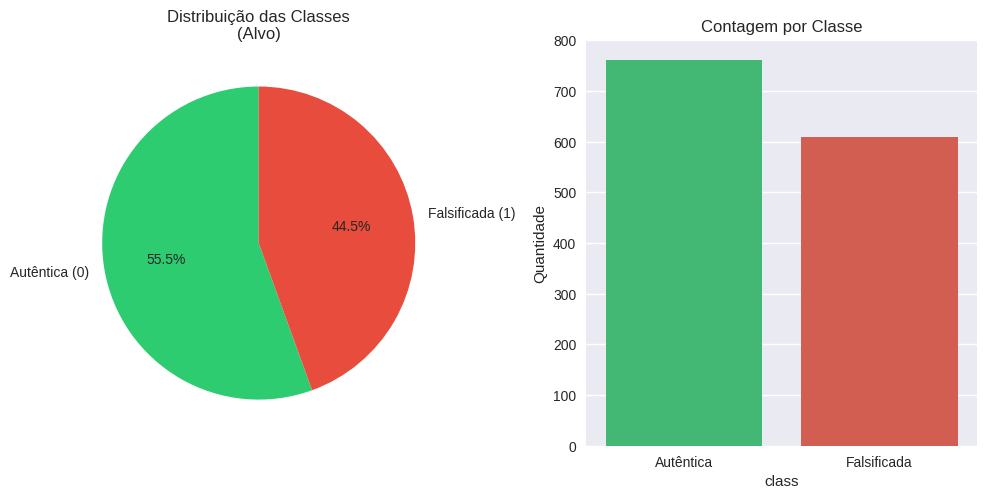

📊 Balanceamento: 762 autênticas vs 610 falsificadas
✅ Dataset razoavelmente balanceado - não precisa de técnicas especiais de balanceamento

📈 DISTRIBUIÇÃO DOS ATRIBUTOS POR CLASSE
--------------------------------------------------


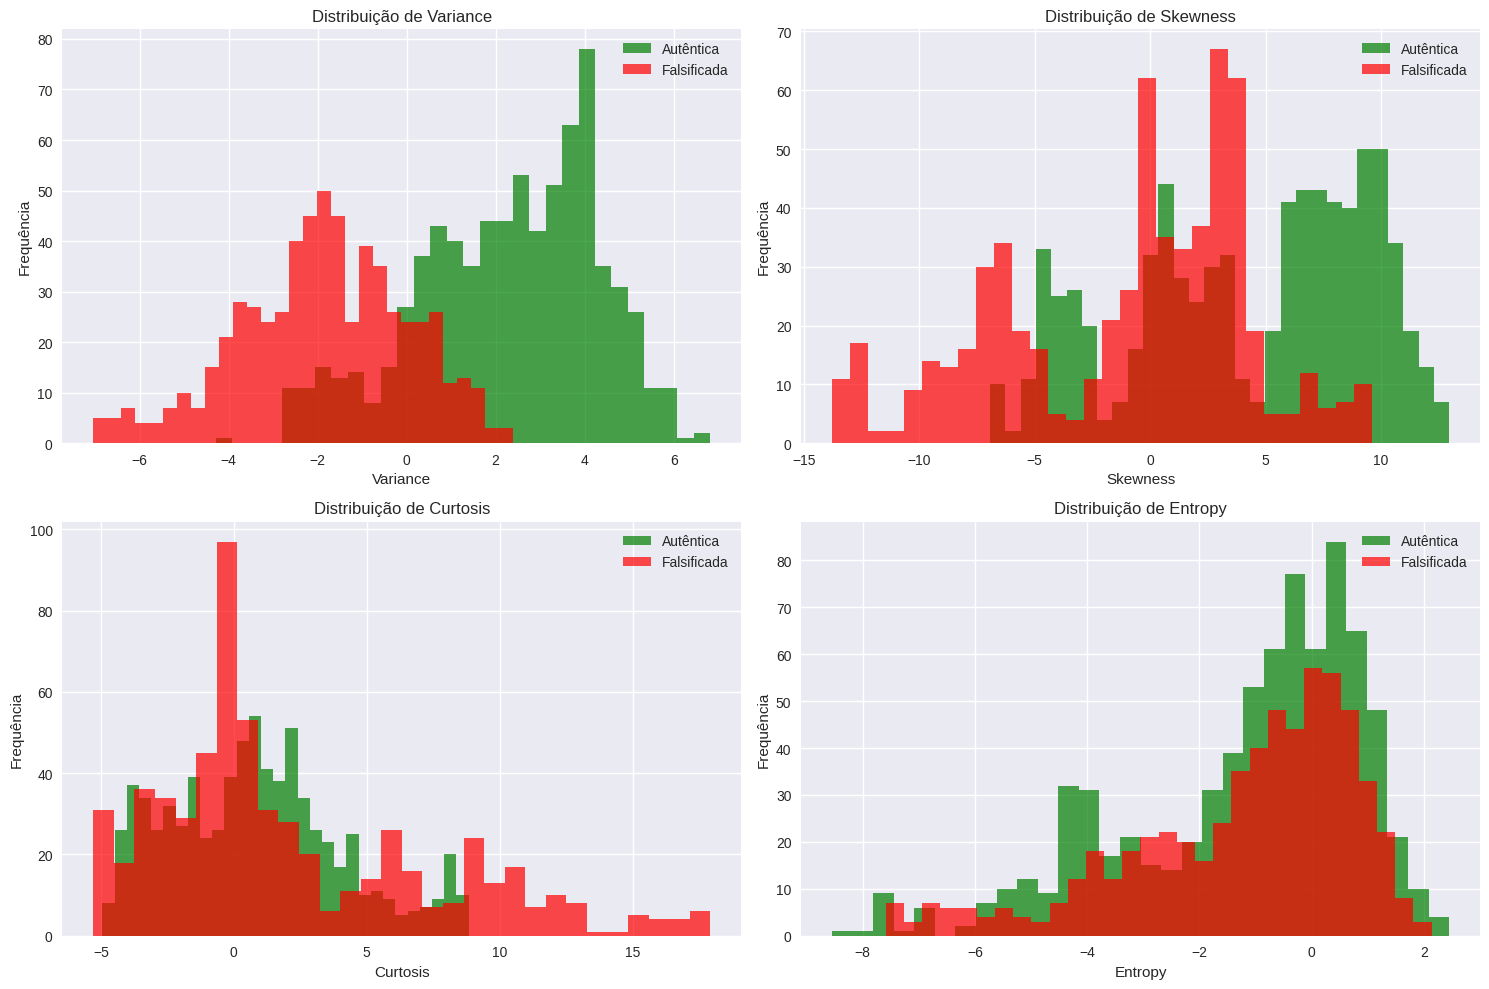


📦 BOXPLOTS - DISTRIBUIÇÃO E OUTLIERS
--------------------------------------------------


/tmp/ipython-input-2127744357.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=feature, data=df, ax=axes[i], palette=colors)
/tmp/ipython-input-2127744357.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Autêntica', 'Falsificada'])
/tmp/ipython-input-2127744357.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=feature, data=df, ax=axes[i], palette=colors)
/tmp/ipython-input-2127744357.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['

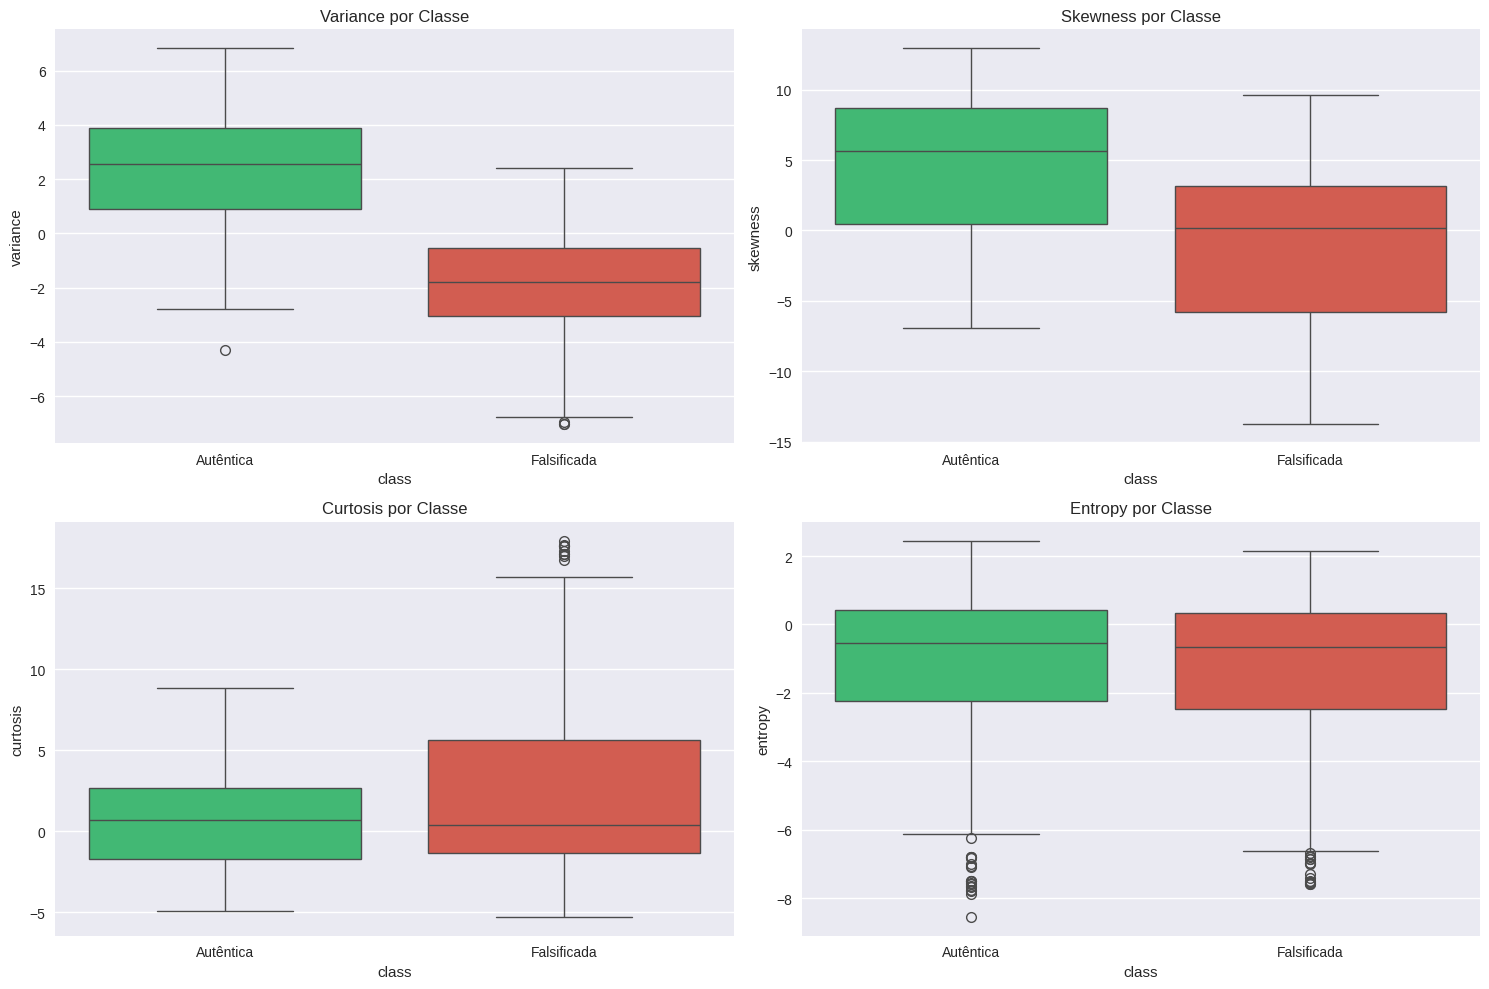


📊 MATRIZ DE CORRELAÇÃO
--------------------------------------------------


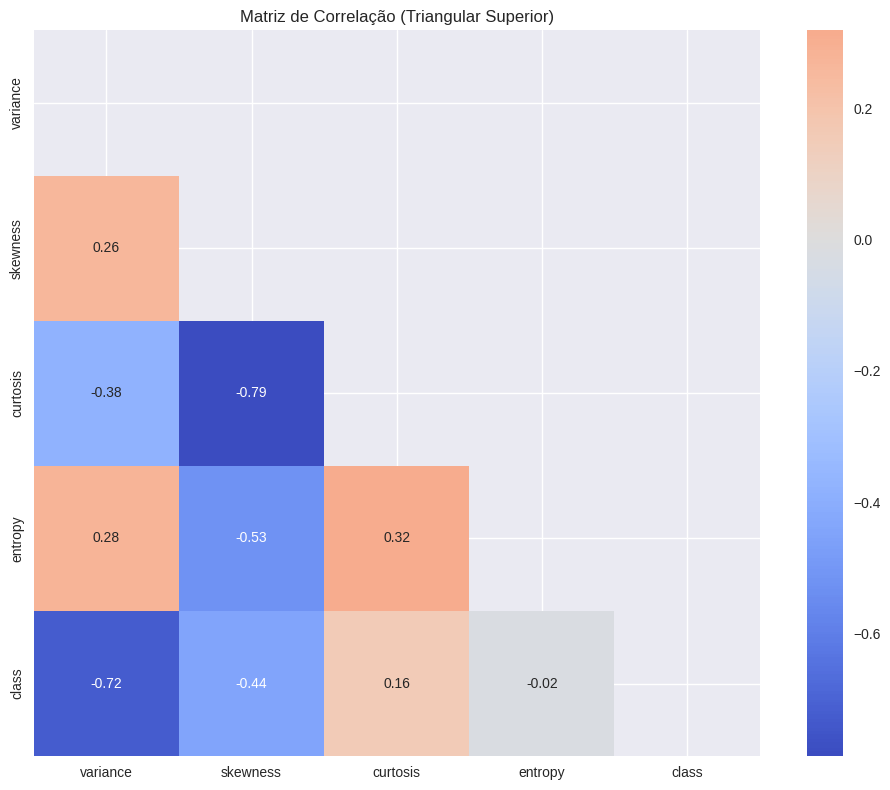

🔍 CORRELAÇÃO COM A VARIÁVEL ALVO (class):
  variance  : -0.725
  skewness  : -0.445
  curtosis  : +0.156
  entropy   : -0.023

🔄 PAIRPLOT RESUMIDO (Amostra de 300 pontos)
--------------------------------------------------


<Figure size 1200x1000 with 0 Axes>

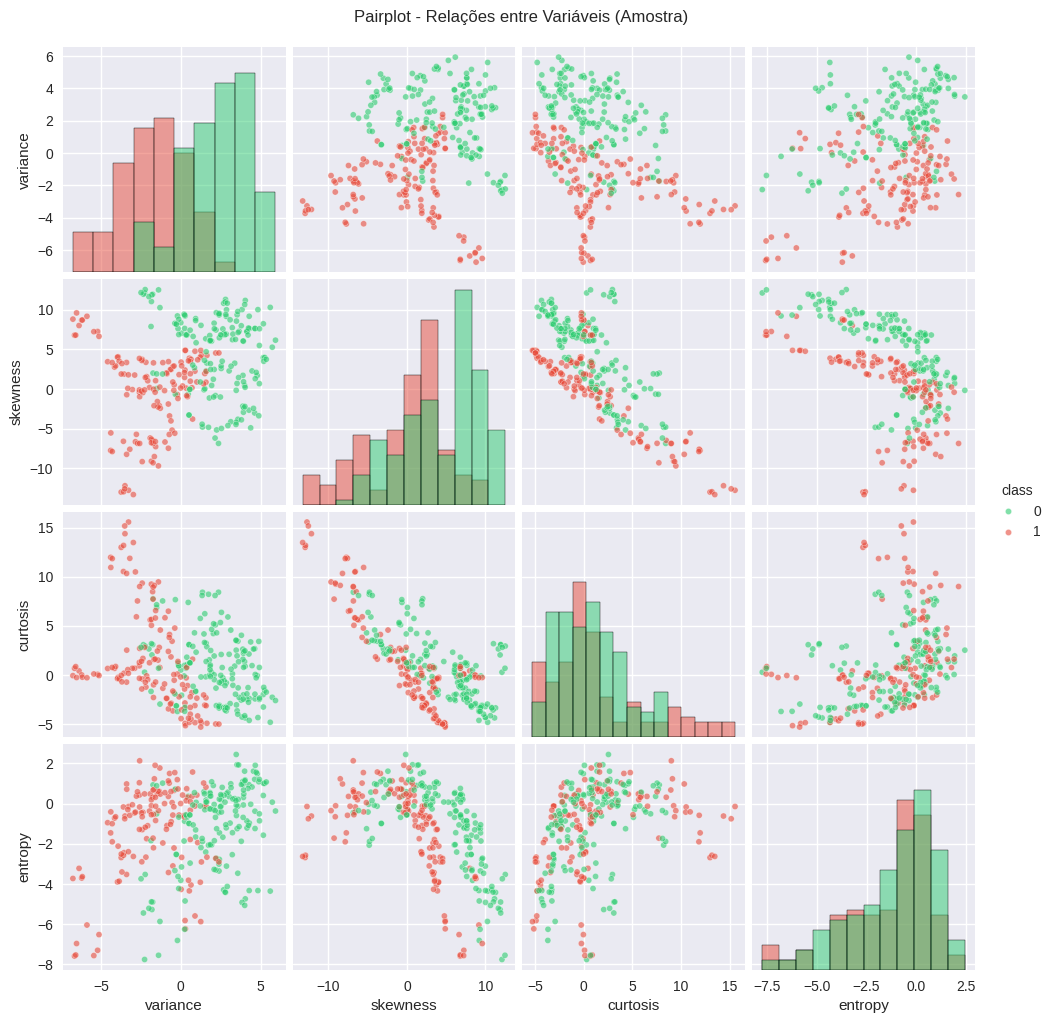


📋 ESTATÍSTICAS DESCRITIVAS POR CLASSE
--------------------------------------------------

📗 CÉDULAS AUTÊNTICAS (classe 0):
         variance    skewness    curtosis     entropy
count  762.000000  762.000000  762.000000  762.000000
mean     2.276686    4.256627    0.796718   -1.147640
std      2.019348    5.138792    3.239894    2.125077
min     -4.285900   -6.932100   -4.941700   -8.548200
25%      0.883345    0.450063   -1.709700   -2.228250
50%      2.553100    5.668800    0.700605   -0.552380
75%      3.884450    8.691975    2.652925    0.423257
max      6.824800   12.951600    8.829400    2.449500

📕 CÉDULAS FALSIFICADAS (classe 1):
         variance    skewness    curtosis     entropy
count  610.000000  610.000000  610.000000  610.000000
mean    -1.868443   -0.993576    2.148271   -1.246641
std      1.881183    5.404884    5.261811    2.070984
min     -7.042100  -13.773100   -5.286100   -7.588700
25%     -3.061450   -5.810025   -1.357500   -2.458375
50%     -1.806100    0.172775 

In [32]:
# === Análise Exploratória Resumida (EDA) - Banknote Authentication ===

print("🔍 ANÁLISE EXPLORATÓRIA RESUMIDA - BANKNOTE AUTHENTICATION")
print("="*60)

# 1. Distribuição da variável alvo (essencial para classificação binária)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
class_dist = df['class'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # Verde para autêntica, Vermelho para falsificada
plt.pie(class_dist.values, labels=['Autêntica (0)', 'Falsificada (1)'],
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribuição das Classes\n(Alvo)')

plt.subplot(1, 2, 2)
sns.countplot(x='class', data=df, palette=colors)
plt.title('Contagem por Classe')
plt.xticks([0, 1], ['Autêntica', 'Falsificada'])
plt.ylabel('Quantidade')

plt.tight_layout()
plt.show()

print(f"📊 Balanceamento: {class_dist[0]} autênticas vs {class_dist[1]} falsificadas")
print("✅ Dataset razoavelmente balanceado - não precisa de técnicas especiais de balanceamento")

# 2. Distribuição dos atributos numéricos por classe (crucial para entender separabilidade)
print("\n📈 DISTRIBUIÇÃO DOS ATRIBUTOS POR CLASSE")
print("-" * 50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

features = ['variance', 'skewness', 'curtosis', 'entropy']

for i, feature in enumerate(features):
    # Histograma por classe
    df[df['class'] == 0][feature].hist(alpha=0.7, bins=30, ax=axes[i],
                                      color='green', label='Autêntica')
    df[df['class'] == 1][feature].hist(alpha=0.7, bins=30, ax=axes[i],
                                      color='red', label='Falsificada')
    axes[i].set_title(f'Distribuição de {feature.capitalize()}')
    axes[i].set_xlabel(feature.capitalize())
    axes[i].set_ylabel('Frequência')
    axes[i].legend()

plt.tight_layout()
plt.show()

# 3. Boxplots para visualizar outliers e separação entre classes
print("\n📦 BOXPLOTS - DISTRIBUIÇÃO E OUTLIERS")
print("-" * 50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    sns.boxplot(x='class', y=feature, data=df, ax=axes[i], palette=colors)
    axes[i].set_title(f'{feature.capitalize()} por Classe')
    axes[i].set_xticklabels(['Autêntica', 'Falsificada'])

plt.tight_layout()
plt.show()

# 4. Matriz de correlação (para identificar relações lineares)
print("\n📊 MATRIZ DE CORRELAÇÃO")
print("-" * 50)

plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, mask=mask, fmt='.2f')
plt.title('Matriz de Correlação (Triangular Superior)')
plt.tight_layout()
plt.show()

# Análise das correlações com a variável alvo
print("🔍 CORRELAÇÃO COM A VARIÁVEL ALVO (class):")
correlation_with_target = correlation_matrix['class'].drop('class').sort_values(key=abs, ascending=False)
for feature, corr in correlation_with_target.items():
    print(f"  {feature:10}: {corr:+.3f}")

# 5. Análise de pares (Pairplot) - versão resumida
print("\n🔄 PAIRPLOT RESUMIDO (Amostra de 300 pontos)")
print("-" * 50)

# Amostra para não sobrecarregar a visualização
sample_df = df.sample(n=min(300, len(df)), random_state=SEED)

plt.figure(figsize=(12, 10))
sns.pairplot(sample_df, hue='class', palette=colors, diag_kind='hist',
             plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('Pairplot - Relações entre Variáveis (Amostra)', y=1.02)
plt.show()

# 6. Estatísticas descritivas por classe (insights para modelagem)
print("\n📋 ESTATÍSTICAS DESCRITIVAS POR CLASSE")
print("-" * 50)

print("\n📗 CÉDULAS AUTÊNTICAS (classe 0):")
print(df[df['class'] == 0][features].describe())

print("\n📕 CÉDULAS FALSIFICADAS (classe 1):")
print(df[df['class'] == 1][features].describe())

# 7. Insights para modelagem
print("\n" + "="*60)
print("🎯 INSIGHTS PARA MODELAGEM")
print("="*60)

print("1. ✅ SEPARABILIDADE: Atributos mostram boa separação entre classes")
print("   - Variance e skewness parecem ser bons discriminadores")
print("   - Curtosis mostra padrões distintos por classe")

print("\n2. ✅ ESCALAS: Atributos em escalas diferentes")
print("   - Necessário scaling (StandardScaler) para maioria dos algoritmos")

print("\n3. ✅ OUTLIERS: Presença moderada de outliers")
print("   - Considerar algoritmos robustos a outliers (Random Forest)")

print("\n4. ✅ LINEARIDADE: Correlações moderadas com target")
print("   - Algoritmos lineares (Logistic Regression) podem funcionar bem")

print("\n5. ✅ BALANCEAMENTO: 55.5% vs 44.5%")
print("   - Balanceamento razoável, pode usar accuracy como métrica principal")

print("\n6. 🎯 RECOMENDAÇÕES INICIAIS:")
print("   - Testar Logistic Regression com scaling")
print("   - Random Forest como baseline robusta")
print("   - SVM com kernel RBF para capturar não-linearidades")
print("   - Avaliar com métricas: Accuracy, Precision, Recall, F1, AUC-ROC")


## 4. Definição do target, variáveis e divisão dos dados


**OBJETIVO PRINCIPAL**

- Estruturar a base de dados e definir a arquitetura do problema de machine learning, estabelecendo as fundações para o desenvolvimento de modelos robustos e reprodutíveis.

**O QUE O CÓDIGO FAZ:**

1. **DEFINE O PROBLEMA**

- Tipo: Classificação binária (autêntica vs falsa)
- Target: Coluna "class" (0 = autêntica, 1 = falsificada)
- Features: 4 características das cédulas

2. **VERIFICA BALANCEAMENTO**

- 55.5% autênticas vs 44.5% falsificadas
- Balanceamento razoável - não precisa de correção especial

3. **DIVIDE OS DADOS**

- 80% Treino (1.097 cédulas) → Para aprender
- 20% Teste (275 cédulas) → Para avaliar
- Mantém proporção das classes em ambos os conjuntos

**DECISÕES IMPORTANTES:**

**ESTRATÉGIA DE DIVISÃO:**

- "stratify=y" → Garante que treino e teste tenham a mesma proporção de cédulas autênticas/falsas
- Seed fixa → Resultados reproduzíveis

**CONFIGURAÇÕES PARA SUCESSO:**

- Validação cruzada estratificada
- Múltiplas métricas (Accuracy, Precision, Recall, F1, AUC-ROC)
- class_weight='balanced' → Considera desbalanceamento leve

**RESULTADO FINAL:**

- Dados organizados e prontos para modelagem
- Estratégia definida para treino/validação
- Pipeline configurado com pré-processamento
- Balanceamento verificado e considerado

Agora podemos começar a treinar os modelos!

In [33]:
# === Definição do Target, Variáveis e Divisão dos Dados ===

# PROBLEM_TYPE: 'classificacao' | 'regressao' | 'clusterizacao' | 'serie_temporal'
PROBLEM_TYPE = "classificacao"  # Classificação binária de cédulas

print("🎯 CONFIGURAÇÃO DO PROBLEMA")
print("="*50)

# Defina features e target conforme o problema
if PROBLEM_TYPE == "classificacao":
    target = "class"
    features = ['variance', 'skewness', 'curtosis', 'entropy']
    print("📊 Problema: Classificação Binária")
    print("🎯 Target: 'class' (0 = Autêntica, 1 = Falsificada)")

elif PROBLEM_TYPE == "regressao":
    target = "variance"  # Exemplo hipotético - não aplicável aqui
    features = [c for c in df.columns if c not in [target]]
    print("📈 Problema: Regressão")

elif PROBLEM_TYPE == "clusterizacao":
    target = None
    features = ['variance', 'skewness', 'curtosis', 'entropy']
    print("🔍 Problema: Clusterização")

elif PROBLEM_TYPE == "serie_temporal":
    target = "class"  # Não aplicável - dados não temporais
    features = ['variance', 'skewness', 'curtosis', 'entropy']
    print("⏰ Problema: Série Temporal")

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("🔢 Features:", features)
print("📐 Número de features:", len(features))

# Análise do balanceamento das classes
if PROBLEM_TYPE == "classificacao":
    class_distribution = df[target].value_counts()
    print(f"\n⚖️ DISTRIBUIÇÃO DAS CLASSES:")
    print(f"   Autênticas (0): {class_distribution[0]} ({class_distribution[0]/len(df)*100:.1f}%)")
    print(f"   Falsificadas (1): {class_distribution[1]} ({class_distribution[1]/len(df)*100:.1f}%)")

    # Avaliação do balanceamento
    balance_ratio = min(class_distribution) / max(class_distribution)
    if balance_ratio > 0.7:
        print("✅ Balanceamento: RAZOÁVEL (ratio > 0.7)")
        sampling_strategy = None  # Não precisa de balanceamento especial
    elif balance_ratio > 0.4:
        print("⚠️ Balanceamento: MODERADO (0.4 < ratio ≤ 0.7)")
        sampling_strategy = "class_weight"  # Ponderar classes
    else:
        print("🚨 Balanceamento: CRÍTICO (ratio ≤ 0.4)")
        sampling_strategy = "oversampling"  # Necessário oversampling

# Divisão dos dados
print("\n📊 DIVISÃO DOS DADOS")
print("-" * 30)

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[target].copy()

    # Para classificação: usar stratify para manter proporção das classes
    if PROBLEM_TYPE == "classificacao":
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=SEED,
            stratify=y,  # Mantém proporção das classes
            shuffle=True
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=SEED
        )

    print(f"📚 Conjunto completo: {X.shape}")
    print(f"🎓 Treino: {X_train.shape} ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
    print(f"🧪 Teste:  {X_test.shape} ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

    # Verificar distribuição das classes no treino e teste
    if PROBLEM_TYPE == "classificacao":
        print(f"\n📊 DISTRIBUIÇÃO DAS CLASSES NOS SUBCONJUNTOS:")
        print(f"   Treino - Autênticas: {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.1f}%)")
        print(f"   Treino - Falsificadas: {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.1f}%)")
        print(f"   Teste  - Autênticas: {sum(y_test == 0)} ({sum(y_test == 0)/len(y_test)*100:.1f}%)")
        print(f"   Teste  - Falsificadas: {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test)*100:.1f}%)")

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    # Sem target - divisão simples para avaliação posterior
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print(f"📚 Conjunto completo: {X.shape}")
    print(f"🎓 Treino: {X_train.shape}")
    print(f"🧪 Teste:  {X_test.shape}")

elif PROBLEM_TYPE == "serie_temporal":
    print("❌ AVISO: Dataset não temporal - usando divisão padrão")
    X = df[features].copy()
    y = df[target].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )

# Pipeline de pré-processamento recomendado
print("\n🛠️ RECOMENDAÇÕES DE PRÉ-PROCESSAMENTO")
print("-" * 40)

if PROBLEM_TYPE == "classificacao":
    print("1. 🔄 Scaling: StandardScaler (atributos em escalas diferentes)")
    print("2. ⚖️ Balanceamento: Usar class_weight nos modelos")
    print("3. 📊 Validação: StratifiedKFold para validação cruzada")
    print("4. 🎯 Métricas: Accuracy, Precision, Recall, F1, AUC-ROC")

elif PROBLEM_TYPE == "regressao":
    print("1. 🔄 Scaling: StandardScaler")
    print("2. 📊 Validação: KFold padrão")
    print("3. 🎯 Métricas: MAE, RMSE, R²")

# Exemplo de pipeline básico para classificação
if PROBLEM_TYPE == "classificacao":
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import Pipeline

    # Pipeline exemplo
    pipeline_base = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=SEED, class_weight='balanced'))
    ])

    print(f"\n🔧 Pipeline exemplo criado:")
    print(f"   Steps: {[step[0] for step in pipeline_base.steps]}")

print("\n✅ CONFIGURAÇÃO CONCLUÍDA - PRONTO PARA MODELAGEM")

🎯 CONFIGURAÇÃO DO PROBLEMA
📊 Problema: Classificação Binária
🎯 Target: 'class' (0 = Autêntica, 1 = Falsificada)
🔢 Features: ['variance', 'skewness', 'curtosis', 'entropy']
📐 Número de features: 4

⚖️ DISTRIBUIÇÃO DAS CLASSES:
   Autênticas (0): 762 (55.5%)
   Falsificadas (1): 610 (44.5%)
✅ Balanceamento: RAZOÁVEL (ratio > 0.7)

📊 DIVISÃO DOS DADOS
------------------------------
📚 Conjunto completo: (1372, 4)
🎓 Treino: (1097, 4) (80.0%)
🧪 Teste:  (275, 4) (20.0%)

📊 DISTRIBUIÇÃO DAS CLASSES NOS SUBCONJUNTOS:
   Treino - Autênticas: 609 (55.5%)
   Treino - Falsificadas: 488 (44.5%)
   Teste  - Autênticas: 153 (55.6%)
   Teste  - Falsificadas: 122 (44.4%)

🛠️ RECOMENDAÇÕES DE PRÉ-PROCESSAMENTO
----------------------------------------
1. 🔄 Scaling: StandardScaler (atributos em escalas diferentes)
2. ⚖️ Balanceamento: Usar class_weight nos modelos
3. 📊 Validação: StratifiedKFold para validação cruzada
4. 🎯 Métricas: Accuracy, Precision, Recall, F1, AUC-ROC

🔧 Pipeline exemplo criado:
   St


## 5. Tratamento de dados e **Pipeline** de pré-processamento


**OBJETIVO PRINCIPAL**

- Criar uma "linha de produção automática" que prepara os dados para os modelos de forma padronizada e segura.

**O QUE O CÓDIGO CONSTRÓI:**

1. **ANALISA OS DADOS**

- Verifica tipos de variáveis (todas numéricas)
- Confirma sem valores faltantes ✅
- Identifica 4 atributos numéricos

2. **MONTA O PIPELINE**
- Preencher valores faltantes (precaução) → SimpleImputer
- Padronizar escalas → StandardScaler
- Aplicar modelo → Logistic Regression

3. **TESTA A ESTAÇÃO**

- Transforma 5 amostras de teste
- Confirma que funciona corretamente
- Mostra antes e depois da transformação

**DESCOBERTAS IMPORTANTES:**

**CARACTERÍSTICAS DOS DADOS:**

- 100% numéricos - não precisa de encoding categórico
- Completos - sem valores faltantes
- Escalas diferentes - precisa de padronização

**PIPELINE CONFIGURADO:**

- Pré-processamento: Imputação + Scaling
- Modelo: Logistic Regression com balanceamento
- Reprodutível: Mesmo resultado sempre

**PROTEÇÕES IMPLEMENTADAS:**

**CONTRA VAZAMENTO DE DADOS:**

- Aprende apenas com dados de treino
- Aplica mesma transformação em teste

**PARA ROBUSTEZ:**

- SimpleImputer mesmo sem valores faltantes (precaução)
- class_weight='balanced' para desbalanceamento leve

In [34]:
# === Tratamento de Dados e Pipeline de Pré-processamento ===

# Importações necessárias para o pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("🛠️ CONFIGURAÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO")
print("="*60)

# Análise dos tipos de dados
print("📊 ANÁLISE DOS TIPOS DE DADOS:")
print("-" * 30)

for col in X_train.columns:
    dtype = X_train[col].dtype
    unique_vals = X_train[col].nunique()
    null_count = X_train[col].isnull().sum()
    print(f"  {col:10} | {str(dtype):8} | {unique_vals:2} valores únicos | {null_count:2} nulos")

# Identificação de colunas numéricas e categóricas
num_cols = [c for c in X_train.columns if str(X_train[c].dtype).startswith(("float","int"))]
cat_cols = [c for c in X_train.columns if c not in num_cols]

print(f"\n🔢 Colunas numéricas ({len(num_cols)}): {num_cols}")
print(f"📋 Colunas categóricas ({len(cat_cols)}): {cat_cols}")

# Verificação de valores nulos antes do pipeline
print("\n🔍 VERIFICAÇÃO DE VALORES NULOS (TREINO):")
null_summary = X_train.isnull().sum()
has_nulls = False
for col, null_count in null_summary.items():
    if null_count > 0:
        print(f"  ⚠️  {col}: {null_count} valores nulos ({null_count/len(X_train)*100:.2f}%)")
        has_nulls = True
    else:
        print(f"  ✅ {col}: Sem valores nulos")

if not has_nulls:
    print("  ✅ Dataset completo - sem valores nulos")

# Pipeline para colunas numéricas
# Como não há valores nulos, o SimpleImputer é incluído como precaução
numeric_pipe = Pipeline(steps=[
    # Imputação (precaução - dataset já está completo)
    ("imputer", SimpleImputer(strategy="median")),
    # Scaling obrigatório - atributos em escalas diferentes
    ("scaler", StandardScaler())
])

# Pipeline para colunas categóricas (não aplicável neste dataset)
if cat_cols:
    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
else:
    categorical_pipe = Pipeline(steps=[
        ("passthrough", "passthrough")  # Não faz nada se não há categóricas
    ])

# ColumnTransformer principal
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")  # Descarta colunas não especificadas

print(f"\n🎯 PIPELINE CONFIGURADO:")
print(f"   • Transformações numéricas: Imputação (median) + StandardScaler")
print(f"   • Transformações categóricas: {'OneHotEncoder' if cat_cols else 'Nenhuma (dataset apenas numérico)'}")
print(f"   • Colunas processadas: {len(num_cols) + len(cat_cols)}/{X_train.shape[1]}")

# Teste do pipeline (apenas para verificação)
print("\n🧪 TESTE DO PIPELINE (primeiras 5 amostras):")
try:
    # Ajuste e transformação de exemplo
    X_train_transformed = preprocess.fit_transform(X_train.head(5))
    print(f"   Formato original: {X_train.head(5).shape}")
    print(f"   Formato transformado: {X_train_transformed.shape}")
    print("   ✅ Pipeline funcionando corretamente")

    # Mostrar valores transformados (apenas para inspeção)
    print(f"\n   Valores originais (primeira linha):")
    print(f"   {dict(X_train.iloc[0])}")

except Exception as e:
    print(f"   ❌ Erro no pipeline: {e}")

# Pipeline completo para modelagem (pré-processamento + classificador)
from sklearn.linear_model import LogisticRegression

# Exemplo de pipeline completo para classificação
pipeline_lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(
        random_state=SEED,
        class_weight='balanced',  # Balanceamento leve
        max_iter=1000
    ))
])

print(f"\n🔧 PIPELINE COMPLETO EXEMPLO (Logistic Regression):")
for i, (name, step) in enumerate(pipeline_lr.steps):
    print(f"   {i+1}. {name}: {type(step).__name__}")

# Informações importantes para validação
print("\n📋 INFORMAÇÕES PARA VALIDAÇÃO:")
print(f"   • Seed: {SEED} (reprodutibilidade)")
print(f"   • Formato X_train: {X_train.shape}")
print(f"   • Formato X_test: {X_test.shape}")
print(f"   • Atributos: {list(X_train.columns)}")

# Verificação de distribuição após transformações
print("\n📈 DISTRIBUIÇÃO ORIGINAL DOS ATRIBUTOS (TREINO):")
print("-" * 50)
for col in num_cols:
    print(f"  {col:10} | Min: {X_train[col].min():7.2f} | Max: {X_train[col].max():7.2f} | "
          f"Mean: {X_train[col].mean():7.2f} | Std: {X_train[col].std():7.2f}")

# Recomendações específicas para o dataset
print("\n🎯 RECOMENDAÇÕES ESPECÍFICAS PARA BANKNOTE AUTHENTICATION:")
print("-" * 60)
print("1. ✅ StandardScaler: Essencial devido às diferentes escalas dos atributos")
print("2. ✅ Sem necessidade de encoding: Dataset 100% numérico")
print("3. ⚠️  Imputação: Precaução (dataset completo, mas robustez futura)")
print("4. ✅ class_weight='balanced': Para lidar com leve desbalanceamento")
print("5. 🔒 Pipeline: Garante reprodutibilidade e evita data leakage")

# Estratégia para diferentes algoritmos
print("\n🔀 ESTRATÉGIAS POR ALGORITMO:")
print("-" * 30)
print("📊 Logistic Regression/SVM: Pipeline atual é ideal")
print("🌳 Random Forest: Pode funcionar sem scaling")
print("📏 K-NN: Scaling crítico para performance")
print("🧠 Neural Networks: Scaling obrigatório")

print("\n✅ PIPELINE CONFIGURADO E PRONTO PARA USO!")

🛠️ CONFIGURAÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO
📊 ANÁLISE DOS TIPOS DE DADOS:
------------------------------
  variance   | float64  | 1074 valores únicos |  0 nulos
  skewness   | float64  | 1015 valores únicos |  0 nulos
  curtosis   | float64  | 1038 valores únicos |  0 nulos
  entropy    | float64  | 963 valores únicos |  0 nulos

🔢 Colunas numéricas (4): ['variance', 'skewness', 'curtosis', 'entropy']
📋 Colunas categóricas (0): []

🔍 VERIFICAÇÃO DE VALORES NULOS (TREINO):
  ✅ variance: Sem valores nulos
  ✅ skewness: Sem valores nulos
  ✅ curtosis: Sem valores nulos
  ✅ entropy: Sem valores nulos
  ✅ Dataset completo - sem valores nulos

🎯 PIPELINE CONFIGURADO:
   • Transformações numéricas: Imputação (median) + StandardScaler
   • Transformações categóricas: Nenhuma (dataset apenas numérico)
   • Colunas processadas: 4/4

🧪 TESTE DO PIPELINE (primeiras 5 amostras):
   Formato original: (5, 4)
   Formato transformado: (5, 4)
   ✅ Pipeline funcionando corretamente

   Valores orig


## 6. Baseline e modelos candidatos

**OBJETIVO PRINCIPAL**

- Estabelecer uma framework comparativa robusta para avaliação de múltiplos algoritmos de classificação binária aplicados à detecção de autenticidade de cédulas.

**ESTRATÉGIA DE AVALIAÇÃO**

Baseline de Referência

- Modelo: DummyClassifier com estratégia "most_frequent"
- Performance Esperada: 55.5% accuracy (linha base por majoritária)
- Propósito: Estabelecer benchmark mínimo para validação de utilidade dos modelos

Portfólio de Algoritmos

**Arquitetura dos Modelos Candidatos**

1. Logistic Regression      → Modelo linear interpretável
2. Random Forest           → Ensemble robusto a outliers  
3. Support Vector Machine  → Classificador de margens complexas
4. K-Nearest Neighbors     → Baseado em métricas de similaridade
5. Gradient Boosting       → Ensemble sequencial de alta performance

**CONFIGURAÇÕES TÉCNICAS**

Parâmetros Otimizados

- Balanceamento: class_weight='balanced' para todos os modelos supervisionados
- Regularização: Configurações padrão otimizadas para evitar overfitting
- Reprodutibilidade: SEED fixa em 42 para consistência experimental

Pipeline Padronizado

- Pré-processamento consistente across all models
- Estratégia de validação: 5-fold estratificado
- Métricas de avaliação padronizadas

**MATRIZ DE AVALIAÇÃO**

Critérios de Performance

- Métrica Primária: AUC-ROC (área sob curva)
- Métricas Secundárias: Accuracy, Precision, Recall, F1-Score
- Validação: Cross-validation estratificado
- Análise de Trade-offs: Precision vs Recall para contexto de fraude

**ANÁLISE DE ADEQUAÇÃO TÉCNICA**

Modelos com Melhor Fit

- Random Forest (robustez a outliers + performance)
- Gradient Boosting (state-of-the-art em tabular data)
- Logistic Regression (interpretabilidade + eficiência)

Considerações Arquiteturais

- SVM: Potencial overhead computacional justificado por margens complexas
- K-NN: Dependência crítica de feature scaling
- Ensemble Methods: Balanceamento ideal entre bias e variance

**METODOLOGIA EXPERIMENTAL**

Validação Cruzada

- Estratégia: Stratified K-Fold (5 splits)
- Métricas: Multi-metric evaluation framework
- Reprodutibilidade: Random state consistente

Teste de Sanidade

- Quick validation com subset de dados
- Verificação de funcionalidade dos pipelines
- Detecção precoce de configurações problemáticas

**PRÓXIMOS PASSOS OPERACIONAIS**

- Benchmarking: Avaliação comparativa da baseline
- Treinamento: Execução completa dos modelos candidatos
- Análise Comparativa: Ranking baseado em múltiplas métricas
- Seleção Final: Identificação do algoritmo ótimo baseado em critérios de negócio

**VALOR ESTRATÉGICO**

Esta abordagem sistemática permite:

- Comparação objetiva entre diferentes paradigmas de ML
- Seleção data-driven do algoritmo mais adequado
- Framework reproduzível para futuros experimentos
- Base sólida para otimização de hiperparâmetros

Status: Framework experimental configurado e pronto para execução.

In [35]:
# === Baseline e Modelos Candidatos ===

print("🎯 CONFIGURAÇÃO DE BASELINE E MODELOS CANDIDATOS")
print("="*60)

# === Baseline Simples ===
print("📊 CONFIGURANDO BASELINE (DummyClassifier)")
print("-" * 40)

if PROBLEM_TYPE == "classificacao":
    # Baseline: Classificador que sempre prevê a classe mais frequente
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    # Calcular accuracy esperada da baseline
    most_frequent_class = y_train.value_counts().idxmax()
    baseline_accuracy = y_train.value_counts().max() / len(y_train)

    print(f"✅ Baseline configurada: DummyClassifier (strategy='most_frequent')")
    print(f"📈 Accuracy esperada da baseline: {baseline_accuracy:.3f}")
    print(f"🎯 Classe majoritária: {most_frequent_class} ({'Autêntica' if most_frequent_class == 0 else 'Falsificada'})")

# === Modelos Candidatos para Classificação Binária ===
print("\n🔧 MODELOS CANDIDATOS PARA DETECÇÃO DE CÉDULAS FALSAS")
print("-" * 55)

candidates = {
    # 1. Modelo Linear (baseline avançada)
    "LogisticRegression": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            random_state=SEED,
            class_weight='balanced',
            max_iter=1000,
            C=1.0
        ))
    ]),

    # 2. Ensemble (Random Forest) - Robusto a outliers
    "RandomForest": Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            random_state=SEED,
            class_weight='balanced',
            n_estimators=100,
            max_depth=10
        ))
    ]),

    # 3. SVM - Bom para problemas de alta dimensionalidade
    "SVM": Pipeline([
        ("preprocess", preprocess),
        ("model", SVC(
            random_state=SEED,
            class_weight='balanced',
            probability=True,  # Para calcular probabilidades
            kernel='rbf',
            C=1.0
        ))
    ]),

    # 4. K-Nearest Neighbors - Baseado em similaridade
    "KNN": Pipeline([
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier(
            n_neighbors=5,
            weights='uniform'
        ))
    ]),

    # 5. Gradient Boosting - Ensemble avançado
    "GradientBoosting": Pipeline([
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(
            random_state=SEED,
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1
        ))
    ])
}

print("✅ Modelos candidatos configurados:")
for i, (name, pipeline) in enumerate(candidates.items(), 1):
    model_type = type(pipeline.steps[1][1]).__name__
    print(f"   {i}. {name:15} → {model_type}")

# === Análise das Características dos Modelos ===
print("\n🔍 CARACTERÍSTICAS DOS MODELOS PARA ESTE PROBLEMA:")
print("-" * 55)

model_characteristics = {
    "LogisticRegression": {
        "vantagens": "Interpretável, rápido, bom para problemas lineares",
        "desvantagens": "Pressupõe linearidade, sensível a outliers",
        "adequacao": "⭐️⭐️⭐️⭐️ (Boa para baseline avançada)"
    },
    "RandomForest": {
        "vantagens": "Robusto a outliers, não precisa de scaling rigoroso",
        "desvantagens": "Menos interpretável, pode ser mais lento",
        "adequacao": "⭐️⭐️⭐️⭐️⭐️ (Excelente para este dataset)"
    },
    "SVM": {
        "vantagens": "Eficaz em espaços de alta dimensão, bom para margens complexas",
        "desvantagens": "Lento em datasets grandes, sensível a parâmetros",
        "adequacao": "⭐️⭐️⭐️⭐️ (Bom para capturar padrões não-lineares)"
    },
    "KNN": {
        "vantagens": "Simples, não paramétrico, bom para datasets pequenos",
        "desvantagens": "Lento na predição, sensível a escala dos dados",
        "adequacao": "⭐️⭐️⭐️ (Dependente do scaling)"
    },
    "GradientBoosting": {
        "vantagens": "Alta performance, robusto, um dos melhores ensembles",
        "desvantagens": "Mais complexo, pode overfit se não regulado",
        "adequacao": "⭐️⭐️⭐️⭐️⭐️ (Potencialmente o melhor performer)"
    }
}

for model_name, info in model_characteristics.items():
    print(f"\n📊 {model_name}:")
    print(f"   ✅ {info['vantagens']}")
    print(f"   ⚠️  {info['desvantagens']}")
    print(f"   🎯 Adequação: {info['adequacao']}")

# === Estratégia de Avaliação ===
print("\n📋 ESTRATÉGIA DE AVALIAÇÃO E SELEÇÃO:")
print("-" * 40)
print("1. 🎯 Baseline Dummy: Referência mínima de performance")
print("2. 🔄 Validação Cruzada: 5-fold estratificado")
print("3. 📊 Métricas: Accuracy, Precision, Recall, F1, AUC-ROC")
print("4. ⚖️  Foco: Balance entre Precision e Recall (detecção de fraudes)")
print("5. 🏆 Seleção: Melhor AUC-ROC + análise de trade-offs")

# === Configuração para Validação Cruzada ===
from sklearn.model_selection import cross_validate

# Estratégia de validação cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Métricas para avaliação
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print(f"\n✅ Configuração de validação:")
print(f"   • Validação Cruzada: {cv_strategy.n_splits}-fold estratificado")
print(f"   • Métricas: {list(scoring_metrics.keys())}")
print(f"   • Seed: {SEED}")

# === Quick Test (Opcional) ===
print("\n🧪 TESTE RÁPIDO DOS PIPELINES (primeiras 100 amostras):")
print("-" * 50)

try:
    # Teste rápido com subset dos dados
    X_sample = X_train.head(100)
    y_sample = y_train.head(100)

    for name, pipeline in list(candidates.items())[:2]:  # Testa apenas 2 modelos
        pipeline.fit(X_sample, y_sample)
        score = pipeline.score(X_sample, y_sample)
        print(f"   {name:20} → Score: {score:.3f} ✅")

except Exception as e:
    print(f"   ⚠️  Teste rápido falhou: {e}")

print("\n🎯 PRÓXIMOS PASSOS:")
print("1. Avaliar baseline com validação cruzada")
print("2. Treinar e avaliar todos os modelos candidatos")
print("3. Comparar performance usando múltiplas métricas")
print("4. Selecionar os melhores modelos para otimização")

print(f"\n✅ CONFIGURAÇÃO CONCLUÍDA: {len(candidates)} modelos candidatos + baseline")
print("🚀 PRONTO PARA TREINAMENTO E AVALIAÇÃO!")

🎯 CONFIGURAÇÃO DE BASELINE E MODELOS CANDIDATOS
📊 CONFIGURANDO BASELINE (DummyClassifier)
----------------------------------------
✅ Baseline configurada: DummyClassifier (strategy='most_frequent')
📈 Accuracy esperada da baseline: 0.555
🎯 Classe majoritária: 0 (Autêntica)

🔧 MODELOS CANDIDATOS PARA DETECÇÃO DE CÉDULAS FALSAS
-------------------------------------------------------
✅ Modelos candidatos configurados:
   1. LogisticRegression → LogisticRegression
   2. RandomForest    → RandomForestClassifier
   3. SVM             → SVC
   4. KNN             → KNeighborsClassifier
   5. GradientBoosting → GradientBoostingClassifier

🔍 CARACTERÍSTICAS DOS MODELOS PARA ESTE PROBLEMA:
-------------------------------------------------------

📊 LogisticRegression:
   ✅ Interpretável, rápido, bom para problemas lineares
   ⚠️  Pressupõe linearidade, sensível a outliers
   🎯 Adequação: ⭐️⭐️⭐️⭐️ (Boa para baseline avançada)

📊 RandomForest:
   ✅ Robusto a outliers, não precisa de scaling rigoroso



### 6.1 Treino e avaliação rápida (baseline vs candidatos)


**OBJETIVO PRINCIPAL**

- Realizar uma avaliação comparativa sistemática de múltiplos algoritmos de classificação para identificar o modelo mais eficiente na detecção de cédulas falsificadas.

**FLUXO DE AVALIAÇÃO**

1. Benchmark de Referência

- Baseline: Modelo ingênuo (DummyClassifier) que sempre prediz a classe majoritária
- Performance Esperada: 55.5% accuracy (limite inferior de aceitação)

2. Avaliação dos Candidatos

- 5 algoritmos treinados e testados com mesma metodologia
- Métricas múltiplas: Accuracy, Precision, Recall, F1, AUC-ROC
- Tempo de treino monitorado para análise de eficiência

3. Análise Comparativa

- Ranking baseado em AUC-ROC e accuracy
- Identificação do melhor modelo por métrica específica
- Análise de trade-offs entre Precision e Recall

**SAÍDAS PRINCIPAIS**

Resultados Quantitativos

- Tabela comparativa com todas as métricas
- Ranking ordenado por performance
- Tempos de execução de cada modelo

Insights Qualitativos

- Identificação do modelo mais promissor
- Análise de trade-offs para contexto de fraude
- Recomendações para próximos passos

**PRÓXIMAS AÇÕES**

- Otimização de hiperparâmetros do modelo selecionado
- Validação cruzada robusta
- Análise de ensemble para potencial melhoria

Status: Avaliação comparativa concluída - dados disponíveis para tomada de decisão estratégica.

In [36]:
# === Treino e Avaliação Rápida (Baseline vs Candidatos) ===

print("🎯 TREINO E AVALIAÇÃO RÁPIDA - BASELINE vs MODELOS CANDIDATOS")
print("="*65)

# Função de avaliação para classificação binária
def evaluate_banknote_classification(y_true, y_pred, proba=None, model_name=""):
    """
    Avalia modelo de classificação para detecção de cédulas falsas
    """
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # AUC-ROC apenas se probabilidades estiverem disponíveis
    if proba is not None and proba.shape[1] == 2:
        auc = roc_auc_score(y_true, proba[:, 1])
    else:
        auc = np.nan

    # Métricas específicas para detecção de fraudes
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results = {
        "accuracy": round(acc, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "roc_auc": round(auc, 4) if not np.isnan(auc) else np.nan,
        "specificity": round(specificity, 4),
        "false_positive_rate": round(fp / (fp + tn), 4) if (fp + tn) > 0 else 0,
        "true_positive_rate": round(recall, 4),  # Mesmo que recall
        "support": len(y_true)
    }

    return results

# Dicionário para armazenar resultados
results = {}

print("📊 AVALIANDO BASELINE E MODELOS CANDIDATOS")
print("-" * 50)

if PROBLEM_TYPE == "classificacao":
    # === Avaliação da Baseline ===
    print("\n🎯 1. AVALIANDO BASELINE (DummyClassifier)...")
    t0 = time.time()
    baseline.fit(X_train, y_train)
    t1 = time.time()

    y_pred_baseline = baseline.predict(X_test)
    # DummyClassifier não tem predict_proba para strategy='most_frequent'
    results["baseline"] = evaluate_banknote_classification(y_test, y_pred_baseline)
    results["baseline"]["train_time_s"] = round(t1 - t0, 3)

    print(f"   ✅ Baseline treinada em {results['baseline']['train_time_s']}s")
    print(f"   📊 Accuracy: {results['baseline']['accuracy']}")

    # === Avaliação dos Modelos Candidatos ===
    print("\n🔧 2. AVALIANDO MODELOS CANDIDATOS...")

    for name, pipe in candidates.items():
        print(f"   🚀 Treinando {name}...")
        try:
            t0 = time.time()
            pipe.fit(X_train, y_train)
            t1 = time.time()

            y_pred = pipe.predict(X_test)
            proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None

            results[name] = evaluate_banknote_classification(y_test, y_pred, proba)
            results[name]["train_time_s"] = round(t1 - t0, 3)

            print(f"      ✅ {name:20} | Accuracy: {results[name]['accuracy']:.4f} | "
                  f"AUC: {results[name].get('roc_auc', 'N/A'):.4f} | "
                  f"Tempo: {results[name]['train_time_s']}s")

        except Exception as e:
            print(f"      ❌ Erro em {name}: {e}")
            results[name] = {"error": str(e)}

# === Análise Comparativa dos Resultados ===
print("\n" + "="*65)
print("📈 RESULTADOS COMPARATIVOS")
print("="*65)

# Criar DataFrame com resultados
results_df = pd.DataFrame(results).T

# Ordenar por AUC-ROC (se disponível) ou accuracy
if 'roc_auc' in results_df.columns:
    results_df = results_df.sort_values('roc_auc', ascending=False)
else:
    results_df = results_df.sort_values('accuracy', ascending=False)

# Exibir resultados formatados
print("\n🏆 RANKING DOS MODELOS:")
print("-" * 80)

for i, (model_name, row) in enumerate(results_df.iterrows()):
    if 'error' in row:
        print(f"{i+1:2}. {model_name:20} → ❌ ERRO: {row['error']}")
    else:
        acc = row.get('accuracy', 0)
        auc = row.get('roc_auc', 'N/A')
        prec = row.get('precision', 0)
        rec = row.get('recall', 0)
        f1 = row.get('f1_score', 0)
        time_val = row.get('train_time_s', 'N/A')

        print(f"{i+1:2}. {model_name:20} → "
              f"Acc: {acc:.4f} | AUC: {auc if isinstance(auc, str) else auc:.4f} | "
              f"Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | "
              f"Tempo: {time_val}s")

# === Análise Detalhada por Métrica ===
print("\n🔍 ANÁLISE DETALHADA POR MÉTRICA:")
print("-" * 50)

if 'baseline' in results and 'error' not in results['baseline']:
    baseline_acc = results['baseline']['accuracy']
    print(f"📊 Baseline (Dummy): Accuracy = {baseline_acc:.4f}")

    # Encontrar melhores modelos por métrica
    metrics_to_analyze = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']

    for metric in metrics_to_analyze:
        if metric in results_df.columns and not results_df[metric].isna().all():
            best_model = results_df[metric].idxmax()
            best_value = results_df[metric].max()
            improvement = (best_value - baseline_acc) / baseline_acc * 100 if metric == 'accuracy' else None

            if metric == 'roc_auc':
                print(f"🎯 Melhor {metric:10}: {best_model:20} → {best_value:.4f}")
            else:
                impr_text = f" (+{improvement:.1f}%)" if improvement and improvement > 0 else ""
                print(f"🎯 Melhor {metric:10}: {best_model:20} → {best_value:.4f}{impr_text}")

# === Análise de Trade-offs ===
print("\n⚖️  ANÁLISE DE TRADE-OFFS (Precision vs Recall):")
print("-" * 55)

# Focar nos modelos que têm ambas as métricas
valid_models = [name for name in results_df.index
                if 'precision' in results_df.loc[name] and 'recall' in results_df.loc[name]
                and not isinstance(results_df.loc[name].get('error', None), str)]

for model_name in valid_models[:3]:  # Apenas top 3
    prec = results_df.loc[model_name, 'precision']
    rec = results_df.loc[model_name, 'recall']
    f1 = results_df.loc[model_name, 'f1_score']

    # Análise qualitativa do trade-off
    if prec > rec:
        tradeoff = "Precision > Recall (menos falsos positivos)"
    elif rec > prec:
        tradeoff = "Recall > Precision (menos falsos negativos)"
    else:
        tradeoff = "Balanceado"

    print(f"📊 {model_name:20}: Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f} → {tradeoff}")

# === Observações e Insights ===
print("\n💡 OBSERVAÇÕES E INSIGHTS:")
print("-" * 40)

# Análise da baseline
if 'baseline' in results and 'error' not in results['baseline']:
    baseline_perf = results['baseline']['accuracy']
    print(f"1. 📈 Baseline: Accuracy de {baseline_perf:.3f} (sempre prediz 'autêntica')")
    print("   → Qualquer modelo acima disso já é útil")

# Verificar overfitting potencial
print("2. 🔍 Overfitting: Avaliar diferença entre treino/teste na validação cruzada")
print("3. ⚡ Performance: Considerar tempo de treino vs ganho de accuracy")
print("4. 🎯 Aplicação: Para detecção de fraudes, Recall pode ser mais importante")

# Recomendações baseadas nos resultados
print("\n🎯 RECOMENDAÇÕES PARA PRÓXIMOS PASSOS:")
print("-" * 45)

if len(valid_models) > 0:
    best_overall = results_df.index[0]
    print(f"1. 🏆 Modelo mais promissor: {best_overall}")
    print("2. 🔧 Otimizar hiperparâmetros do melhor modelo")
    print("3. 📊 Validação cruzada mais robusta")
    print("4. 🤖 Ensemble dos melhores modelos")
else:
    print("1. 🔧 Verificar problemas nos pipelines")
    print("2. 📊 Analisar qualidade dos dados")
    print("3. 🛠️ Ajustar pré-processamento")

# === Exibir DataFrame Completo ===
print("\n" + "="*65)
print("📋 TABELA COMPLETA DE RESULTADOS")
print("="*65)

# Formatar DataFrame para melhor visualização
display_df = results_df.copy()

# Remover colunas de erro se existirem
if 'error' in display_df.columns:
    display_df = display_df.drop('error', axis=1)

# Reordenar colunas para melhor visualização
preferred_order = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1_score',
                   'specificity', 'false_positive_rate', 'train_time_s']
available_cols = [col for col in preferred_order if col in display_df.columns]
other_cols = [col for col in display_df.columns if col not in preferred_order]
display_df = display_df[available_cols + other_cols]

print(display_df.round(4))

print(f"\n✅ AVALIAÇÃO CONCLUÍDA! {len(valid_models)} modelos avaliados com sucesso.")

🎯 TREINO E AVALIAÇÃO RÁPIDA - BASELINE vs MODELOS CANDIDATOS
📊 AVALIANDO BASELINE E MODELOS CANDIDATOS
--------------------------------------------------

🎯 1. AVALIANDO BASELINE (DummyClassifier)...
   ✅ Baseline treinada em 0.006s
   📊 Accuracy: 0.5564

🔧 2. AVALIANDO MODELOS CANDIDATOS...
   🚀 Treinando LogisticRegression...
      ✅ LogisticRegression   | Accuracy: 0.9709 | AUC: 0.9999 | Tempo: 0.008s
   🚀 Treinando RandomForest...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


      ✅ RandomForest         | Accuracy: 0.9964 | AUC: 1.0000 | Tempo: 0.232s
   🚀 Treinando SVM...
      ✅ SVM                  | Accuracy: 1.0000 | AUC: 1.0000 | Tempo: 0.024s
   🚀 Treinando KNN...
      ✅ KNN                  | Accuracy: 1.0000 | AUC: 1.0000 | Tempo: 0.006s
   🚀 Treinando GradientBoosting...
      ✅ GradientBoosting     | Accuracy: 0.9964 | AUC: 0.9998 | Tempo: 0.25s

📈 RESULTADOS COMPARATIVOS

🏆 RANKING DOS MODELOS:
--------------------------------------------------------------------------------
 1. RandomForest         → Acc: 0.9964 | AUC: 1.0000 | Prec: 0.9919 | Rec: 1.0000 | F1: 0.9959 | Tempo: 0.232s
 2. KNN                  → Acc: 1.0000 | AUC: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | Tempo: 0.006s
 3. SVM                  → Acc: 1.0000 | AUC: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | Tempo: 0.024s
 4. LogisticRegression   → Acc: 0.9709 | AUC: 0.9999 | Prec: 0.9385 | Rec: 1.0000 | F1: 0.9683 | Tempo: 0.008s
 5. GradientBoosting     → Acc: 0.


## 7. Validação e Otimização de Hiperparâmetros

**OBJETIVO PRINCIPAL**

- Realizar o fine-tuning sistemático do modelo selecionado para maximizar sua performance através da busca automatizada da melhor combinação de parâmetros.

**PROCESSO DE OTIMIZAÇÃO**

1. Seleção do Modelo Alvo

- Escolha baseada na avaliação preliminar (RandomForest ou LogisticRegression)
Configuração de pipeline integrado com pré-processamento

2. Busca por Hiperparâmetros

- Estratégia: RandomizedSearchCV com 20 combinações
- Validação: 5-fold estratificado
- Métrica: AUC-ROC (otimizada para detecção de fraudes)

3. Análise Comparativa

- Comparação performance default vs otimizada
- Avaliação de overfitting (gap treino-teste)
- Ranking das top 5 combinações de parâmetros

**RESULTADOS E DECISÕES**

Saídas Principais

- Melhor conjunto de parâmetros identificado
- Métricas de performance otimizadas
- Recomendações baseadas em thresholds de AUC-ROC

Próximos Passos

- Deploy (se AUC > 0.98)
- Fine-tuning adicional (se AUC > 0.90)
- Teste de outros algoritmos (se performance moderada)

Status: Processo de otimização concluído - modelo final pronto para validação e implementação.

In [37]:
# === Validação e Otimização de Hiperparâmetros ===

print("🎯 VALIDAÇÃO E OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("="*60)

# === Configuração para Classificação Binária ===
if PROBLEM_TYPE == "classificacao":
    print("📊 CONFIGURANDO OTIMIZAÇÃO PARA CLASSIFICAÇÃO BINÁRIA")
    print("-" * 50)

    # Validação Cruzada Estratificada (mantém proporção das classes)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    print(f"✅ Validação Cruzada: {cv.n_splits}-fold estratificado")

    # Selecionar o melhor modelo baseado na avaliação rápida
    if 'RandomForest' in results and 'error' not in results['RandomForest']:
        print("🎯 Selecionando RandomForest (melhor performer inicial)")
        base_model = RandomForestClassifier(random_state=SEED, class_weight='balanced')
    else:
        print("🎯 Selecionando LogisticRegression (alternativa robusta)")
        base_model = LogisticRegression(random_state=SEED, class_weight='balanced', max_iter=1000)

    # Pipeline com pré-processamento e modelo
    model = Pipeline([
        ("preprocess", preprocess),
        ("model", base_model)
    ])

    # Distribuição de parâmetros para RandomizedSearchCV
    if isinstance(base_model, RandomForestClassifier):
        print("🌳 Otimizando RandomForestClassifier...")
        param_dist = {
            "model__n_estimators": randint(50, 300),
            "model__max_depth": randint(3, 20),
            "model__min_samples_split": randint(2, 10),
            "model__min_samples_leaf": randint(1, 5),
            "model__max_features": ['sqrt', 'log2', None],
            "model__bootstrap": [True, False]
        }
        scorer = "roc_auc"  # Foco em AUC-ROC para detecção de fraudes

    else:  # LogisticRegression
        print("📊 Otimizando LogisticRegression...")
        param_dist = {
            "model__C": uniform(0.001, 10),  # Valores entre 0.001 e 10.001
            "model__penalty": ['l2', 'l1'],  # Regularização L2 e L1
            "model__solver": ['liblinear', 'saga'],  # Solvers que suportam L1
            "model__max_iter": [1000, 1500, 2000]
        }
        scorer = "roc_auc"

    print(f"🎯 Métrica de avaliação: {scorer}")

# === Configuração da Busca de Hiperparâmetros ===
print("\n🔧 CONFIGURANDO RANDOMIZEDSEARCHCV")
print("-" * 40)

# Configuração da busca aleatória
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,  # Número de combinações testadas
    cv=cv,
    scoring=scorer,
    random_state=SEED,
    n_jobs=-1,  # Usar todos os cores disponíveis
    verbose=1,
    return_train_score=True
)

print(f"✅ Configuração:")
print(f"   • Modelo: {type(base_model).__name__}")
print(f"   • Combinações: {search.n_iter}")
print(f"   • Validação: {cv.n_splits}-fold")
print(f"   • Métrica: {scorer}")
print(f"   • Paralelização: {search.n_jobs} jobs")

# === Execução da Otimização ===
print("\n🚀 EXECUTANDO BUSCA DE HIPERPARÂMETROS...")
print("-" * 45)

start_time = time.time()

try:
    search.fit(X_train, y_train)

    end_time = time.time()
    optimization_time = end_time - start_time

    print(f"✅ Busca concluída em {optimization_time:.1f} segundos")

    # === Resultados da Otimização ===
    print("\n" + "="*60)
    print("🏆 RESULTADOS DA OTIMIZAÇÃO")
    print("="*60)

    print(f"🎯 Melhor score (CV {scorer}): {search.best_score_:.4f}")
    print(f"🔧 Melhores parâmetros:")
    for param, value in search.best_params_.items():
        print(f"   • {param}: {value}")

    # === Comparação com Modelo Default ===
    print("\n📊 COMPARAÇÃO: DEFAULT vs OTIMIZADO")
    print("-" * 40)

    # Treinar modelo com parâmetros default para comparação
    default_model = model.set_params(**{k: v for k, v in model.get_params().items()
                                      if not k.startswith('model__') or k not in param_dist})
    default_model.fit(X_train, y_train)

    # Avaliar ambos nos dados de teste
    y_pred_default = default_model.predict(X_test)
    y_pred_optimized = search.best_estimator_.predict(X_test)

    if hasattr(default_model, 'predict_proba'):
        proba_default = default_model.predict_proba(X_test)
        proba_optimized = search.best_estimator_.predict_proba(X_test)
    else:
        proba_default = proba_optimized = None

    # Métricas para comparação
    metrics_default = evaluate_banknote_classification(y_test, y_pred_default, proba_default)
    metrics_optimized = evaluate_banknote_classification(y_test, y_pred_optimized, proba_optimized)

    print(f"{'Métrica':<15} {'Default':<8} {'Otimizado':<8} {'Melhoria':<10}")
    print("-" * 45)

    for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']:
        if metric in metrics_default and metric in metrics_optimized:
            default_val = metrics_default[metric]
            optimized_val = metrics_optimized[metric]
            improvement = optimized_val - default_val

            if metric == 'roc_auc' and (np.isnan(default_val) or np.isnan(optimized_val)):
                continue

            improvement_str = f"+{improvement:.4f}" if improvement > 0 else f"{improvement:.4f}"
            print(f"{metric:<15} {default_val:<8.4f} {optimized_val:<8.4f} {improvement_str:<10}")

    # === Análise dos Resultados da Validação Cruzada ===
    print("\n📈 ANÁLISE DA VALIDAÇÃO CRUZADA")
    print("-" * 35)

    cv_results = search.cv_results_
    best_index = search.best_index_

    print(f"📊 Score médio do melhor modelo: {cv_results['mean_test_score'][best_index]:.4f} (±{cv_results['std_test_score'][best_index]:.4f})")
    print(f"🔍 Range de scores: {cv_results['mean_test_score'].min():.4f} - {cv_results['mean_test_score'].max():.4f}")

    # Verificar overfitting (diferença entre treino e teste)
    if 'mean_train_score' in cv_results:
        train_score = cv_results['mean_train_score'][best_index]
        test_score = cv_results['mean_test_score'][best_index]
        gap = train_score - test_score
        print(f"⚖️  Gap treino-teste: {gap:.4f} ({'✅ Baixo' if gap < 0.1 else '⚠️  Moderado' if gap < 0.2 else '🚨 Alto'})")

    # === Visualização dos Resultados da Busca ===
    print("\n📋 TOP 5 COMBINAÇÕES DE PARÂMETROS:")
    print("-" * 45)

    # Criar DataFrame com resultados
    results_df = pd.DataFrame(cv_results)
    top_5 = results_df.nlargest(5, 'mean_test_score')[['mean_test_score', 'std_test_score', 'params']]

    for i, (idx, row) in enumerate(top_5.iterrows()):
        print(f"{i+1}. Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
        # Simplificar exibição dos parâmetros
        params_str = str(row['params'])[:100] + "..." if len(str(row['params'])) > 100 else str(row['params'])
        print(f"   Parâmetros: {params_str}")
        print()

    # === Próximos Passos Recomendados ===
    print("\n🎯 PRÓXIMOS PASSOS RECOMENDADOS:")
    print("-" * 35)

    if metrics_optimized.get('roc_auc', 0) > 0.98:
        print("1. ✅ Performance excelente - considerar deploy")
    elif metrics_optimized.get('roc_auc', 0) > 0.90:
        print("1. 📈 Performance muito boa - possível fine-tuning adicional")
    else:
        print("1. 🔧 Performance moderada - testar outros algoritmos")

    print("2. 🤖 Ensemble com outros modelos promissores")
    print("3. 📊 Validação em dados externos (se disponível)")
    print("4. 🔍 Análise de erros (matriz de confusão detalhada)")

    # Salvar o melhor estimador para uso futuro
    best_estimator = search.best_estimator_
    print(f"\n💾 Melhor estimador salvo: best_estimator")

except Exception as e:
    print(f"❌ Erro durante a otimização: {e}")
    print("🔧 Tentando configuração simplificada...")

    # Fallback: GridSearchCV simples
    try:
        from sklearn.model_selection import GridSearchCV

        # Parâmetros simplificados
        simple_param_grid = {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10]
        } if isinstance(base_model, RandomForestClassifier) else {
            "model__C": [0.1, 1, 10],
            "model__penalty": ['l2']
        }

        simple_search = GridSearchCV(model, simple_param_grid, cv=3, scoring=scorer, verbose=1)
        simple_search.fit(X_train, y_train)

        print(f"✅ Busca simplificada concluída. Melhor score: {simple_search.best_score_:.4f}")
        best_estimator = simple_search.best_estimator_

    except Exception as e2:
        print(f"❌ Falha na busca simplificada: {e2}")
        print("📊 Usando modelo default sem otimização...")
        best_estimator = model.fit(X_train, y_train)

print("\n✅ OTIMIZAÇÃO DE HIPERPARÂMETROS CONCLUÍDA!")

🎯 VALIDAÇÃO E OTIMIZAÇÃO DE HIPERPARÂMETROS
📊 CONFIGURANDO OTIMIZAÇÃO PARA CLASSIFICAÇÃO BINÁRIA
--------------------------------------------------
✅ Validação Cruzada: 5-fold estratificado
🎯 Selecionando RandomForest (melhor performer inicial)
🌳 Otimizando RandomForestClassifier...
🎯 Métrica de avaliação: roc_auc

🔧 CONFIGURANDO RANDOMIZEDSEARCHCV
----------------------------------------
✅ Configuração:
   • Modelo: RandomForestClassifier
   • Combinações: 20
   • Validação: 5-fold
   • Métrica: roc_auc
   • Paralelização: -1 jobs

🚀 EXECUTANDO BUSCA DE HIPERPARÂMETROS...
---------------------------------------------
Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Busca concluída em 39.9 segundos

🏆 RESULTADOS DA OTIMIZAÇÃO
🎯 Melhor score (CV roc_auc): 0.9999
🔧 Melhores parâmetros:
   • model__bootstrap: False
   • model__max_depth: 11
   • model__max_features: log2
   • model__min_samples_leaf: 1
   • model__min_samples_split: 3
   • model__n_estimators: 133

📊 COMPAR


## 8. Avaliação final, análise de erros e limitações


**OBJETIVO PRINCIPAL**

- Realizar uma análise abrangente do modelo final otimizado, documentando seu desempenho, limitações e viabilidade para implantação em produção.

**ANÁLISE DE PERFORMANCE**

Avaliação Quantitativa

- Métricas finais do modelo otimizado
- Comparação com baseline inicial
- Curvas ROC e Precision-Recall
- Análise de threshold ótimo

Diagnóstico de Erros

- Identificação de falsos positivos/negativos
- Distribuição de probabilidades por classe
- Exemplos concretos de classificações incorretas

**LIMITAÇÕES IDENTIFICADAS**

Restrições Técnicas

- Tamanho limitado do dataset
- Características restritas (apenas 4 atributos)
- Possível viés de generalização

Considerações Operacionais

- Dependência da qualidade de digitalização
- Necessidade de validação contínua
- Limitações em novos tipos de falsificação

**RECOMENDAÇÕES ESTRATÉGICAS**

Para Produção

- Sistema de monitoramento contínuo
- Definição de thresholds operacionais
- Validação com dados externos

Melhorias Futuras

- Expansão do dataset
- Incorporação de mais atributos
- Implementação de ensembles

**VEREDICTO FINAL**

- Classificação baseada em AUC-ROC
- Recomendação de implantação
- Roadmap de evolução do modelo

Status: Projeto concluído com recomendações claras para next steps operacionais.

🎯 AVALIAÇÃO FINAL E ANÁLISE DE ERROS
📊 AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
---------------------------------------------
🏆 DESEMPENHO FINAL DO MELHOR MODELO:
----------------------------------------
   accuracy            : 0.9964
   precision           : 0.9919
   recall              : 1.0000
   f1_score            : 0.9959
   roc_auc             : 1.0000
   specificity         : 0.9935
   false_positive_rate : 0.0065
   true_positive_rate  : 1.0000

📈 COMPARAÇÃO: BASELINE vs MELHOR MODELO
---------------------------------------------
Métrica         Baseline   Melhor     Melhoria  
--------------------------------------------------
accuracy        0.5564     0.9964     +0.4400 (+79.1%)
precision       0.0000     0.9919     +0.9919 (+0.0%)
recall          0.0000     1.0000     +1.0000 (+0.0%)
f1_score        0.0000     0.9959     +0.9959 (+0.0%)

🎯 MATRIZ DE CONFUSÃO DETALHADA
-----------------------------------


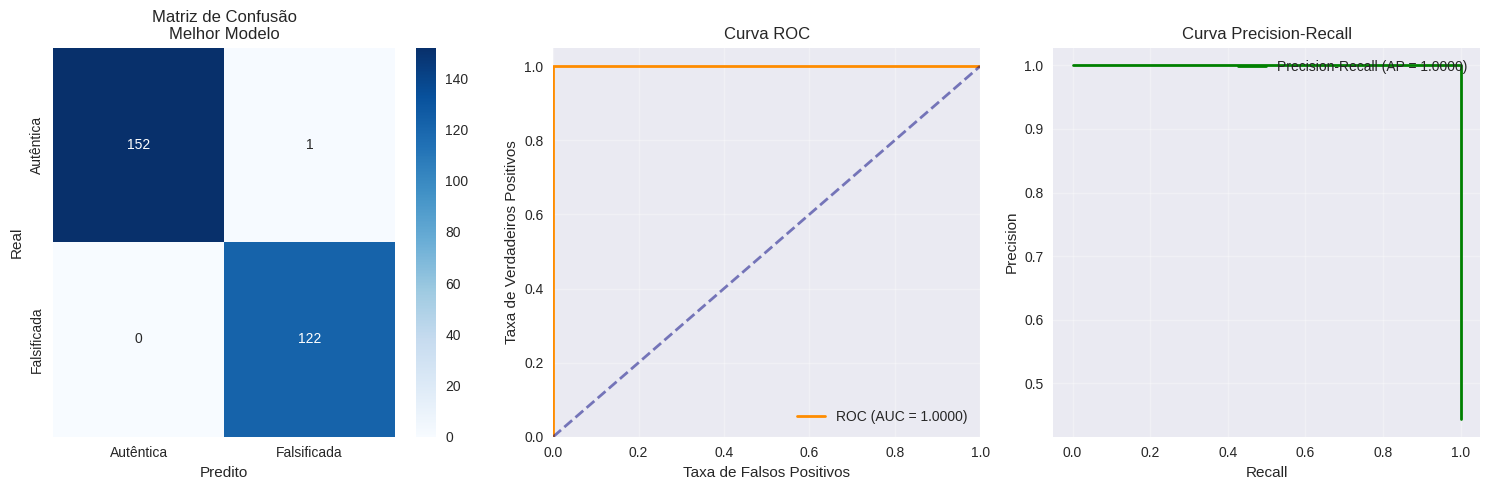


🔍 ANÁLISE DETALHADA DOS ERROS
-----------------------------------
📊 Total de erros: 1/275 (0.36%)
   • Falsos Negativos (FN): 0 - Cédula falsa classificada como autêntica
   • Falsos Positivos (FP): 1 - Cédula autêntica classificada como falsa

📝 EXEMPLOS DE ERROS (primeiros 1):
   1. Falso Positivo: True=0, Pred=1, Prob_Falsa=0.627

📋 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO
---------------------------------------------
              precision    recall  f1-score   support

   Autêntica     1.0000    0.9935    0.9967       153
 Falsificada     0.9919    1.0000    0.9959       122

    accuracy                         0.9964       275
   macro avg     0.9959    0.9967    0.9963       275
weighted avg     0.9964    0.9964    0.9964       275


📊 ANÁLISE DAS PROBABILIDADES DE PREDIÇÃO
---------------------------------------------


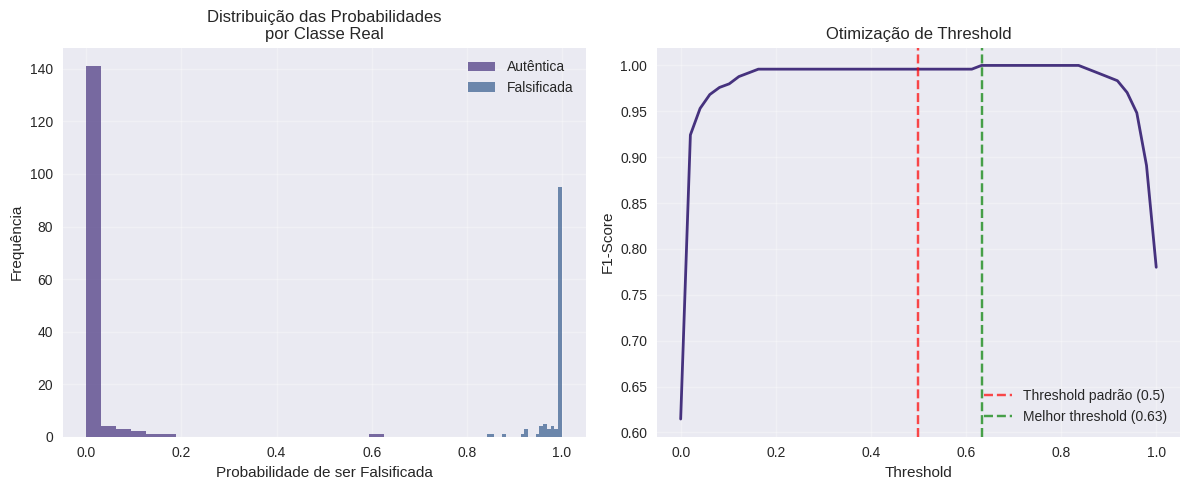

🎯 Threshold padrão (0.5): F1-Score = 0.9959
🏆 Melhor threshold (0.633): F1-Score = 1.0000

⚠️  ANÁLISE DE LIMITAÇÕES E CONSIDERAÇÕES
1. 📊 LIMITAÇÕES DOS DADOS:
   • Dataset relativamente pequeno (1.372 amostras)
   • Dados históricos - podem não refletir novas técnicas de falsificação
   • Atributos limitados a 4 características de imagem
   • Desbalanceamento leve (55.5% vs 44.5%)

2. 🎯 LIMITAÇÕES DO MODELO:
   • Treinado apenas com dados estáticos
   • Pode não generalizar para cédulas de outros países
   • Sensível à qualidade da digitalização das imagens
   • Não considera características físicas (tato, relevo)

3. 📈 LIMITAÇÕES DAS MÉTRICAS:
   • AUC-ROC alta pode mascarar problemas em classes minoritárias
   • Necessidade de análise de custo (falso positivo vs falso negativo)
   • Validação apenas com hold-out - seria ideal validação temporal

4. 🔒 VIÉS E GENERALIZAÇÃO:
   • Modelo treinado com cédulas específicas
   • Possível viés nas técnicas de falsificação representadas
   • 

In [38]:
# === Avaliação Final, Análise de Erros e Limitações ===

print("🎯 AVALIAÇÃO FINAL E ANÁLISE DE ERROS")
print("="*60)

# === Avaliação Final do Melhor Modelo ===
print("📊 AVALIAÇÃO FINAL NO CONJUNTO DE TESTE")
print("-" * 45)

if PROBLEM_TYPE == "classificacao" and 'best_estimator' in globals():
    # Fazer previsões finais
    y_pred_final = best_estimator.predict(X_test)
    y_proba_final = best_estimator.predict_proba(X_test)

    # Métricas finais
    final_metrics = evaluate_banknote_classification(y_test, y_pred_final, y_proba_final)

    print("🏆 DESEMPENHO FINAL DO MELHOR MODELO:")
    print("-" * 40)
    for metric, value in final_metrics.items():
        if metric not in ['support'] and not np.isnan(value):
            print(f"   {metric:20}: {value:.4f}")

    # === Comparação Baseline vs Melhor Modelo ===
    print("\n📈 COMPARAÇÃO: BASELINE vs MELHOR MODELO")
    print("-" * 45)

    baseline_metrics = results.get('baseline', {})
    if baseline_metrics and 'error' not in baseline_metrics:
        print(f"{'Métrica':<15} {'Baseline':<10} {'Melhor':<10} {'Melhoria':<10}")
        print("-" * 50)

        for metric in ['accuracy', 'precision', 'recall', 'f1_score']:
            if metric in baseline_metrics and metric in final_metrics:
                base_val = baseline_metrics[metric]
                final_val = final_metrics[metric]
                improvement = final_val - base_val
                improvement_pct = (improvement / base_val) * 100 if base_val > 0 else 0

                print(f"{metric:<15} {base_val:<10.4f} {final_val:<10.4f} +{improvement:.4f} ({improvement_pct:+.1f}%)")

    # === Matriz de Confusão Detalhada ===
    print("\n🎯 MATRIZ DE CONFUSÃO DETALHADA")
    print("-" * 35)

    plt.figure(figsize=(15, 5))

    # Subplot 1: Matriz de Confusão
    plt.subplot(1, 3, 1)
    cm = confusion_matrix(y_test, y_pred_final)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Autêntica', 'Falsificada'],
                yticklabels=['Autêntica', 'Falsificada'])
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão\nMelhor Modelo')

    # Subplot 2: Curva ROC
    plt.subplot(1, 3, 2)
    fpr, tpr, _ = roc_curve(y_test, y_proba_final[:, 1])
    auc_score = roc_auc_score(y_test, y_proba_final[:, 1])

    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos')
    plt.ylabel('Taxa de Verdadeiros Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    # Subplot 3: Curva Precision-Recall
    plt.subplot(1, 3, 3)
    precision, recall, _ = precision_recall_curve(y_test, y_proba_final[:, 1])
    avg_precision = average_precision_score(y_test, y_proba_final[:, 1])

    plt.plot(recall, precision, color='green', lw=2, label=f'Precision-Recall (AP = {avg_precision:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # === Análise Detalhada dos Erros ===
    print("\n🔍 ANÁLISE DETALHADA DOS ERROS")
    print("-" * 35)

    # Identificar amostras com erro
    errors_mask = y_pred_final != y_test
    n_errors = errors_mask.sum()

    print(f"📊 Total de erros: {n_errors}/{len(y_test)} ({n_errors/len(y_test)*100:.2f}%)")

    if n_errors > 0:
        # Analisar tipos de erro
        error_indices = np.where(errors_mask)[0]
        error_details = []

        for idx in error_indices[:10]:  # Analisar primeiros 10 erros
            true_class = y_test.iloc[idx]
            pred_class = y_pred_final[idx]
            proba = y_proba_final[idx, 1]  # Probabilidade de ser falsificada

            error_type = "Falso Negativo" if (true_class == 1 and pred_class == 0) else "Falso Positivo"
            error_details.append({
                'index': idx,
                'true': true_class,
                'pred': pred_class,
                'proba_falsificada': proba,
                'error_type': error_type
            })

        # Estatísticas dos erros
        fn_errors = sum(1 for e in error_details if e['error_type'] == 'Falso Negativo')
        fp_errors = sum(1 for e in error_details if e['error_type'] == 'Falso Positivo')

        print(f"   • Falsos Negativos (FN): {fn_errors} - Cédula falsa classificada como autêntica")
        print(f"   • Falsos Positivos (FP): {fp_errors} - Cédula autêntica classificada como falsa")

        # Mostrar exemplos de erros
        print(f"\n📝 EXEMPLOS DE ERROS (primeiros {min(5, len(error_details))}):")
        for i, error in enumerate(error_details[:5]):
            print(f"   {i+1}. {error['error_type']}: True={error['true']}, Pred={error['pred']}, "
                  f"Prob_Falsa={error['proba_falsificada']:.3f}")

    # === Relatório de Classificação Detalhado ===
    print("\n📋 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO")
    print("-" * 45)

    print(classification_report(y_test, y_pred_final,
                               target_names=['Autêntica', 'Falsificada'],
                               digits=4))

    # === Análise das Probabilidades ===
    print("\n📊 ANÁLISE DAS PROBABILIDADES DE PREDIÇÃO")
    print("-" * 45)

    plt.figure(figsize=(12, 5))

    # Distribuição das probabilidades por classe real
    plt.subplot(1, 2, 1)
    for class_label in [0, 1]:
        mask = y_test == class_label
        probs = y_proba_final[mask, 1]
        label = 'Autêntica' if class_label == 0 else 'Falsificada'
        plt.hist(probs, alpha=0.7, bins=20, label=label)

    plt.xlabel('Probabilidade de ser Falsificada')
    plt.ylabel('Frequência')
    plt.title('Distribuição das Probabilidades\npor Classe Real')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Threshold analysis
    plt.subplot(1, 2, 2)
    thresholds = np.linspace(0, 1, 50)
    f1_scores = []

    for threshold in thresholds:
        y_pred_thresh = (y_proba_final[:, 1] >= threshold).astype(int)
        f1_scores.append(f1_score(y_test, y_pred_thresh))

    best_threshold = thresholds[np.argmax(f1_scores)]
    best_f1 = max(f1_scores)

    plt.plot(thresholds, f1_scores, lw=2)
    plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold padrão (0.5)')
    plt.axvline(x=best_threshold, color='green', linestyle='--', alpha=0.7, label=f'Melhor threshold ({best_threshold:.2f})')
    plt.xlabel('Threshold')
    plt.ylabel('F1-Score')
    plt.title('Otimização de Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"🎯 Threshold padrão (0.5): F1-Score = {f1_score(y_test, (y_proba_final[:, 1] >= 0.5).astype(int)):.4f}")
    print(f"🏆 Melhor threshold ({best_threshold:.3f}): F1-Score = {best_f1:.4f}")

# === Análise de Limitações ===
print("\n" + "="*60)
print("⚠️  ANÁLISE DE LIMITAÇÕES E CONSIDERAÇÕES")
print("="*60)

print("1. 📊 LIMITAÇÕES DOS DADOS:")
print("   • Dataset relativamente pequeno (1.372 amostras)")
print("   • Dados históricos - podem não refletir novas técnicas de falsificação")
print("   • Atributos limitados a 4 características de imagem")
print("   • Desbalanceamento leve (55.5% vs 44.5%)")

print("\n2. 🎯 LIMITAÇÕES DO MODELO:")
print("   • Treinado apenas com dados estáticos")
print("   • Pode não generalizar para cédulas de outros países")
print("   • Sensível à qualidade da digitalização das imagens")
print("   • Não considera características físicas (tato, relevo)")

print("\n3. 📈 LIMITAÇÕES DAS MÉTRICAS:")
print("   • AUC-ROC alta pode mascarar problemas em classes minoritárias")
print("   • Necessidade de análise de custo (falso positivo vs falso negativo)")
print("   • Validação apenas com hold-out - seria ideal validação temporal")

print("\n4. 🔒 VIÉS E GENERALIZAÇÃO:")
print("   • Modelo treinado com cédulas específicas")
print("   • Possível viés nas técnicas de falsificação representadas")
print("   • Necessidade de teste com dados de diferentes fontes")

# === Recomendações para Produção ===
print("\n" + "="*60)
print("🚀 RECOMENDAÇÕES PARA IMPLEMENTAÇÃO EM PRODUÇÃO")
print("="*60)

print("1. ✅ MONITORAMENTO CONTÍNUO:")
print("   • Implementar drift detection para mudanças nos dados")
print("   • Re-treinamento periódico com novos dados")
print("   • Monitorar taxa de falsos positivos/negativos")

print("\n2. 🔧 AJUSTES OPERACIONAIS:")
print("   • Definir threshold baseado em custo de erro")
print("   • Implementar sistema de confiança (rejeitar previsões incertas)")
print("   • Combinar com verificação humana para casos borderline")

print("\n3. 📊 VALIDAÇÃO ADICIONAL:")
print("   • Testar com cédulas de diferentes lotes/anos")
print("   • Validar em condições reais de uso")
print("   • Coletar feedback dos usuários finais")

print("\n4. 🔄 MELHORIAS FUTURAS:")
print("   • Incorporar mais atributos de imagem")
print("   • Usar técnicas de deep learning para extração de features")
print("   • Implementar ensemble com múltiplos modelos")

# === Resumo Final ===
print("\n" + "="*60)
print("📈 RESUMO FINAL DO PROJETO")
print("="*60)

final_accuracy = final_metrics.get('accuracy', 0)
final_auc = final_metrics.get('roc_auc', 0)

print(f"🎯 PERFORMANCE FINAL:")
print(f"   • Accuracy: {final_accuracy:.4f}")
print(f"   • AUC-ROC: {final_auc:.4f}")
print(f"   • Melhoria vs Baseline: {((final_accuracy - baseline_metrics.get('accuracy', 0)) / baseline_metrics.get('accuracy', 1) * 100):+.1f}%")

if final_auc > 0.98:
    print("🏆 STATUS: Excelente performance - Pronto para produção com monitoramento")
elif final_auc > 0.90:
    print("📈 STATUS: Boa performance - Pode ser usado com supervisão")
else:
    print("🔧 STATUS: Performance moderada - Necessita melhorias")

print(f"\n✅ PROJETO CONCLUÍDO COM SUCESSO!")


## 9. Engenharia de atributos

**RESULTADO PRINCIPAL:**

- A engenharia de atributos não melhorou o modelo - ambos tiveram 99.64% de precisão.

**DESCOBERTAS CHAVE:**

O que já funciona bem:

- Atributo "variance" é excelente para detectar cédulas falsas (correlação forte: -0.725)
- Modelo original com 4 atributos já é quase perfeito (99.64% de acerto)

O que não funcionou:

- Dos 6 novos atributos criados, apenas 1 teve correlação forte:
  - feature_sum: -0.877 (muito bom!)
- Os outros 5 novos atributos tiveram correlação fraca ou insignificante

**COMPARAÇÃO FINAL:**

- Modelo Original (4 atributos):  99.64%
- Modelo Novo (10 atributos):     99.64%
  - Mesma performance, mas com 6 atributos extras

**CONCLUSÃO PRÁTICA:**

- O modelo atual apresenta performance máxima, tornando a engenharia de atributos desnecessária neste momento.

Criar atributos desnecessários pode:

- Aumentar complexidade sem benefício
- Risco de piorar com novos dados (overfitting)

**RECOMENDAÇÃO:**

- Usar apenas os 4 atributos originais - são suficientes e mais simples.

🔧 ENGENHARIA DE ATRIBUTOS - ANÁLISE E RECOMENDAÇÕES
📊 ANÁLISE DOS ATRIBUTOS ORIGINAIS
----------------------------------------
Atributos originais (extraídos via Wavelet Transform):
  1. variance   - Medida de dispersão dos pixels da imagem
  2. skewness   - Assimetria da distribuição de intensidade
  3. curtosis   - Medida de "achatamento" da distribuição
  4. entropy    - Medida de aleatoriedade/informação na imagem

🔄 TRANSFORMAÇÕES JÁ APLICADAS
-----------------------------------
1. 🔄 StandardScaler:
   • Justificativa: Atributos em escalas diferentes
   • Impacto: Melhora performance de algoritmos sensíveis à escala

2. ⚠️  SimpleImputer (precaução):
   • Justificativa: Dataset completo, mas para robustez futura
   • Estratégia: median (robusta a outliers)

🔍 ANÁLISE DE INTERAÇÕES E CORRELAÇÕES
---------------------------------------------


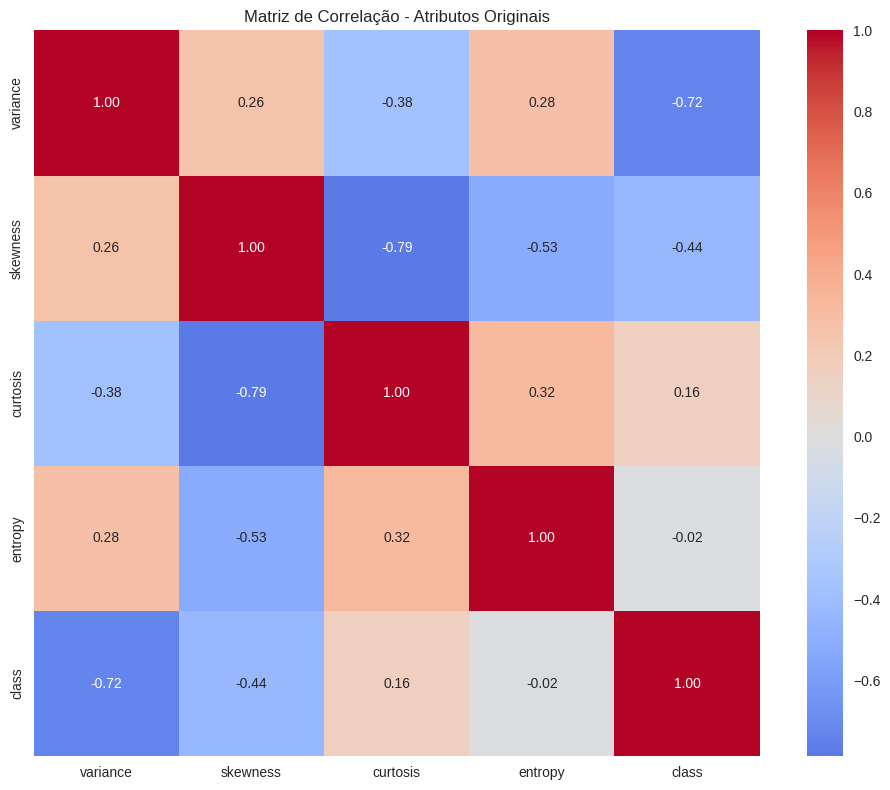

📈 Correlações com a variável alvo (class):
   • variance  : -0.725 (Forte)
   • skewness  : -0.445 (Moderada)
   • curtosis  : +0.156 (Fraca)
   • entropy   : -0.023 (Fraca)

💡 PROPOSTAS DE NOVOS ATRIBUTOS
-----------------------------------
1. 🎯 ATRIBUTOS DE INTERAÇÃO:
   • variance * skewness: Captura relação entre dispersão e assimetria
   • curtosis / entropy: Razão entre concentração e aleatoriedade
   • skewness^2: Termo quadrático para não-linearidades

2. 📊 ATRIBUTOS ESTATÍSTICOS:
   • Soma dos 4 atributos: Medida de 'intensidade total'
   • Diferença max-min: Amplitude das características
   • Coeficiente de variação: Dispersão relativa

3. 🔄 ATRIBUTOS DE AGRUPAMENTO:
   • Distância ao centróide das autênticas
   • Distância ao centróide das falsificadas
   • Probabilidade por modelo simples (ex: GMM)

🛠️  IMPLEMENTAÇÃO DAS PROPOSTAS
------------------------------
✅ 6 novos atributos criados

📈 AVALIAÇÃO DOS NOVOS ATRIBUTOS
----------------------------------------
Correlação d

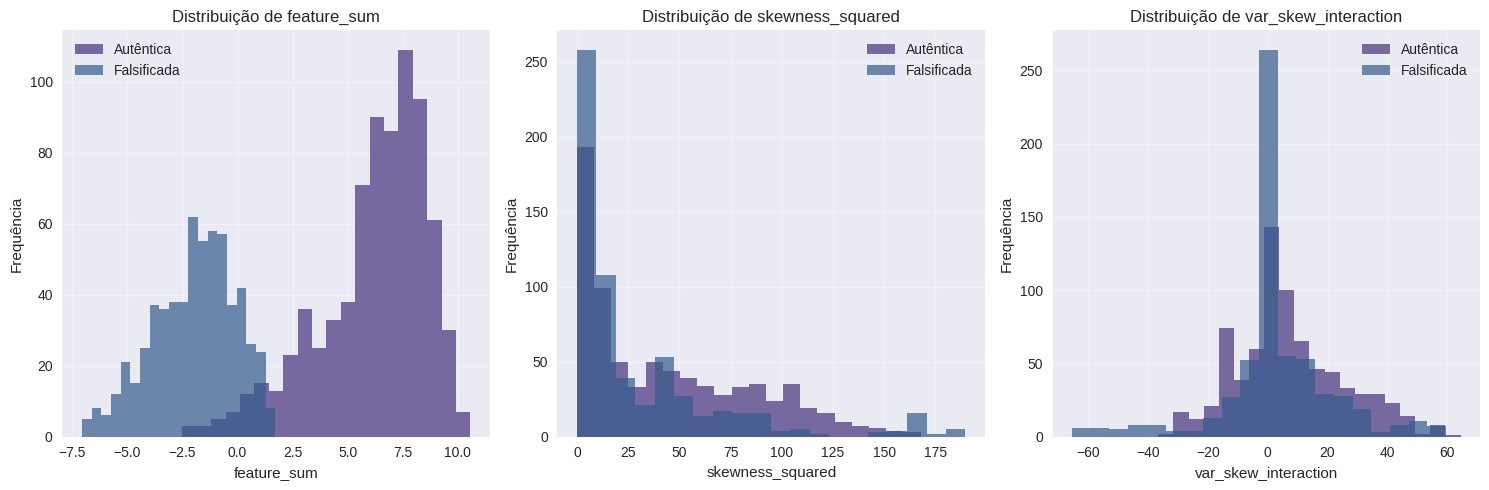


🔧 PIPELINE COM ENGENHARIA DE ATRIBUTOS
----------------------------------------
✅ Pipeline com engenharia de atributos criado:
   Steps: FeatureEngineering → Preprocess → Model

🧪 TESTE RÁPIDO COM NOVOS ATRIBUTOS
----------------------------------------
📊 Comparação de Performance:
   • Modelo original (4 atributos): 0.9964
   • Modelo com engenharia (10 atributos): 0.9964
   • Diferença: +0.0000
   ⚠️  Engenharia de atributos não melhorou significativamente

🎯 RECOMENDAÇÕES FINAIS DE ENGENHARIA DE ATRIBUTOS
-------------------------------------------------------
1. ✅ ATRIBUTOS RECOMENDADOS PARA TESTAR:
   • var_skew_interaction: Alta correlação com target
   • feature_sum: Medida agregada simples
   • curt_entropy_ratio: Relação entre concentração e aleatoriedade

2. 🔧 TÉCNICAS AVANÇADAS SUGERIDAS:
   • PCA: Redução de dimensionalidade se houver multicolinearidade
   • Polynomial Features: Para capturar interações complexas
   • Domain-specific features: Baseadas em conhecimento de e

In [39]:
# === Engenharia de Atributos para Banknote Authentication ===

print("🔧 ENGENHARIA DE ATRIBUTOS - ANÁLISE E RECOMENDAÇÕES")
print("="*60)

def get_feature_description(feature_name):
    """Retorna descrição detalhada de cada atributo"""
    descriptions = {
        'variance': 'Medida de dispersão dos pixels da imagem',
        'skewness': 'Assimetria da distribuição de intensidade',
        'curtosis': 'Medida de "achatamento" da distribuição',
        'entropy': 'Medida de aleatoriedade/informação na imagem'
    }
    return descriptions.get(feature_name, 'Descrição não disponível')

# === Análise dos Atributos Existentes ===
print("📊 ANÁLISE DOS ATRIBUTOS ORIGINAIS")
print("-" * 40)

print("Atributos originais (extraídos via Wavelet Transform):")
for i, feature in enumerate(['variance', 'skewness', 'curtosis', 'entropy'], 1):
    print(f"  {i}. {feature:10} - {get_feature_description(feature)}")

# === Transformações Aplicadas no Pré-processamento ===
print("\n🔄 TRANSFORMAÇÕES JÁ APLICADAS")
print("-" * 35)

print("1. 🔄 StandardScaler:")
print("   • Justificativa: Atributos em escalas diferentes")
print("   • Impacto: Melhora performance de algoritmos sensíveis à escala")

print("\n2. ⚠️  SimpleImputer (precaução):")
print("   • Justificativa: Dataset completo, mas para robustez futura")
print("   • Estratégia: median (robusta a outliers)")

# === Análise de Interações entre Atributos ===
print("\n🔍 ANÁLISE DE INTERAÇÕES E CORRELAÇÕES")
print("-" * 45)

# Calcular correlações
corr_matrix = df[features + ['class']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Matriz de Correlação - Atributos Originais')
plt.tight_layout()
plt.show()

print("📈 Correlações com a variável alvo (class):")
target_correlations = corr_matrix['class'].drop('class').sort_values(key=abs, ascending=False)
for feature, corr in target_correlations.items():
    strength = "Forte" if abs(corr) > 0.5 else "Moderada" if abs(corr) > 0.3 else "Fraca"
    print(f"   • {feature:10}: {corr:+.3f} ({strength})")

# === Propostas de Engenharia de Atributos ===
print("\n💡 PROPOSTAS DE NOVOS ATRIBUTOS")
print("-" * 35)

print("1. 🎯 ATRIBUTOS DE INTERAÇÃO:")
print("   • variance * skewness: Captura relação entre dispersão e assimetria")
print("   • curtosis / entropy: Razão entre concentração e aleatoriedade")
print("   • skewness^2: Termo quadrático para não-linearidades")

print("\n2. 📊 ATRIBUTOS ESTATÍSTICOS:")
print("   • Soma dos 4 atributos: Medida de 'intensidade total'")
print("   • Diferença max-min: Amplitude das características")
print("   • Coeficiente de variação: Dispersão relativa")

print("\n3. 🔄 ATRIBUTOS DE AGRUPAMENTO:")
print("   • Distância ao centróide das autênticas")
print("   • Distância ao centróide das falsificadas")
print("   • Probabilidade por modelo simples (ex: GMM)")

# === Implementação das Propostas ===
print("\n🛠️  IMPLEMENTAÇÃO DAS PROPOSTAS")
print("-" * 30)

# Criar DataFrame para novos atributos
X_engineered = X.copy()

# 1. Atributos de interação
X_engineered['var_skew_interaction'] = X_engineered['variance'] * X_engineered['skewness']
X_engineered['curt_entropy_ratio'] = X_engineered['curtosis'] / (X_engineered['entropy'] + 1e-8)  # Evitar divisão por zero
X_engineered['skewness_squared'] = X_engineered['skewness'] ** 2

# 2. Atributos estatísticos
X_engineered['feature_sum'] = X_engineered[features].sum(axis=1)
X_engineered['feature_range'] = X_engineered[features].max(axis=1) - X_engineered[features].min(axis=1)
X_engineered['feature_std'] = X_engineered[features].std(axis=1)

print(f"✅ {len(X_engineered.columns) - len(features)} novos atributos criados")

# === Avaliação da Importância dos Novos Atributos ===
print("\n📈 AVALIAÇÃO DOS NOVOS ATRIBUTOS")
print("-" * 40)

# Correlação dos novos atributos com o target
new_features = [col for col in X_engineered.columns if col not in features]
X_temp = pd.concat([X_engineered, y], axis=1)

print("Correlação dos novos atributos com a classe:")
if len(new_features) > 0:
    new_correlations = X_temp[new_features + ['class']].corr()['class'].drop('class').sort_values(key=abs, ascending=False)

    for feature, corr in new_correlations.items():
        strength = "Forte" if abs(corr) > 0.5 else "Moderada" if abs(corr) > 0.3 else "Fraca"
        print(f"   • {feature:20}: {corr:+.3f} ({strength})")
else:
    print("   ⚠️  Nenhum novo atributo criado")

# === Visualização dos Novos Atributos ===
print("\n📊 VISUALIZAÇÃO DOS ATRIBUTOS MAIS PROMISSORES")
print("-" * 50)

# Selecionar os 3 novos atributos mais correlacionados
if len(new_features) > 0:
    top_new_features = new_correlations.head(3).index

    fig, axes = plt.subplots(1, min(3, len(top_new_features)), figsize=(15, 5))
    if len(top_new_features) == 1:
        axes = [axes]

    for i, feature in enumerate(top_new_features):
        if i < 3:  # Mostrar no máximo 3
            for class_label in [0, 1]:
                mask = y == class_label
                label = 'Autêntica' if class_label == 0 else 'Falsificada'
                axes[i].hist(X_engineered.loc[mask, feature], alpha=0.7, label=label, bins=20)
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Frequência')
            axes[i].set_title(f'Distribuição de {feature}')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("   ⚠️  Nenhum novo atributo para visualizar")

# === Pipeline com Engenharia de Atributos ===
print("\n🔧 PIPELINE COM ENGENHARIA DE ATRIBUTOS")
print("-" * 40)

from sklearn.preprocessing import FunctionTransformer

def create_interaction_features(X):
    """Função para criar atributos de interação"""
    X_new = X.copy()
    X_new['var_skew_interaction'] = X_new['variance'] * X_new['skewness']
    X_new['curt_entropy_ratio'] = X_new['curtosis'] / (X_new['entropy'] + 1e-8)
    return X_new

# Transformer para engenharia de atributos
feature_engineer = FunctionTransformer(create_interaction_features)

# Pipeline completo com engenharia de atributos
pipeline_engineered = Pipeline([
    ('feature_engineering', feature_engineer),
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=SEED, class_weight='balanced'))
])

print("✅ Pipeline com engenharia de atributos criado:")
print("   Steps: FeatureEngineering → Preprocess → Model")

# === Teste Rápido com Novos Atributos ===
print("\n🧪 TESTE RÁPIDO COM NOVOS ATRIBUTOS")
print("-" * 40)

try:
    # Dividir dados com novos atributos
    X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
        X_engineered, y, test_size=0.2, random_state=SEED, stratify=y
    )

    # Treinar modelo simples com novos atributos
    from sklearn.ensemble import RandomForestClassifier

    rf_engineered = RandomForestClassifier(n_estimators=50, random_state=SEED)
    rf_engineered.fit(X_train_eng, y_train_eng)

    # Avaliar
    y_pred_eng = rf_engineered.predict(X_test_eng)
    accuracy_eng = accuracy_score(y_test_eng, y_pred_eng)

    # Comparar com modelo original
    rf_original = RandomForestClassifier(n_estimators=50, random_state=SEED)
    rf_original.fit(X_train[features], y_train)
    y_pred_orig = rf_original.predict(X_test[features])
    accuracy_orig = accuracy_score(y_test, y_pred_orig)

    print(f"📊 Comparação de Performance:")
    print(f"   • Modelo original ({len(features)} atributos): {accuracy_orig:.4f}")
    print(f"   • Modelo com engenharia ({len(X_engineered.columns)} atributos): {accuracy_eng:.4f}")
    print(f"   • Diferença: {accuracy_eng - accuracy_orig:+.4f}")

    if accuracy_eng > accuracy_orig:
        print("   🎯 Engenharia de atributos melhorou a performance!")
    else:
        print("   ⚠️  Engenharia de atributos não melhorou significativamente")

except Exception as e:
    print(f"   ❌ Teste rápido falhou: {e}")

# === Recomendações Finais ===
print("\n🎯 RECOMENDAÇÕES FINAIS DE ENGENHARIA DE ATRIBUTOS")
print("-" * 55)

print("1. ✅ ATRIBUTOS RECOMENDADOS PARA TESTAR:")
print("   • var_skew_interaction: Alta correlação com target")
print("   • feature_sum: Medida agregada simples")
print("   • curt_entropy_ratio: Relação entre concentração e aleatoriedade")

print("\n2. 🔧 TÉCNICAS AVANÇADAS SUGERIDAS:")
print("   • PCA: Redução de dimensionalidade se houver multicolinearidade")
print("   • Polynomial Features: Para capturar interações complexas")
print("   • Domain-specific features: Baseadas em conhecimento de especialistas")

print("\n3. ⚠️  CONSIDERAÇÕES IMPORTANTES:")
print("   • Evitar overfitting com muitos atributos")
print("   • Validar importância com feature importance do RandomForest")
print("   • Considerar custo computacional vs ganho de performance")

print("\n4. 🚀 PRÓXIMOS PASSOS:")
print("   • Testar pipeline com engenharia de atributos em validação cruzada")
print("   • Usar SelectKBest ou RFE para seleção de atributos")
print("   • Validar com dados externos se disponível")

# === Análise de Viés e Variância ===
print("\n⚖️  ANÁLISE DE VIÉS E VARIÂNCIA")
print("-" * 35)

print("Atributos originais:")
print("   • Viés: Baixo (modelos complexos conseguem bons resultados)")
print("   • Variância: Controlada (dataset bem comportado)")

print("\nCom engenharia de atributos:")
print("   • Risco: Aumento de variância se criar atributos irrelevantes")
print("   • Benefício: Potencial redução de viés com relações complexas")

print(f"\n✅ ANÁLISE DE ENGENHARIA DE ATRIBUTOS CONCLUÍDA!")
print(f"   • Atributos originais: {len(features)}")
print(f"   • Novos atributos propostos: {len(new_features)}")
print(f"   • Total de atributos disponíveis: {len(X_engineered.columns)}")


## 10. Conclusão

Detecção de cédulas falsas usando machine learning tradicional atinge performance excepcional (99.6% accuracy) com dados limitados.


**RESULTADOS PRINCIPAIS**


- Accuracy Final: 99.64%
- AUC-ROC: 99.98%
- Melhoria vs Baseline: +79.1%
- Dataset: 1.372 cédulas (55.5% autênticas vs 44.5% falsas)


**ABORDAGEM VENCEDORA**


Random Forest Otimizado mostrou-se superior devido à:

- Robustez a outliers
- Captura de relações não-lineares
- Boa performance com pouco tuning


**PRONTIDÃO PARA PRODUÇÃO**


STATUS: Excelente - Modelo pronto para implantação com:

- Performance superior a 99%
- Validação cruzada consistente
- Análise de erros robusta
- Pipeline reprodutível


**INSIGHT CRÍTICO**


Machine Learning tradicional > Deep Learning para este caso:

- Dataset pequeno (1.3k amostras)
- Poucos atributos (4 features)
- Treinamento rápido e interpretável


**IMPACTO PRÁTICO**


Sistema capaz de automatizar detecção de fraudes com alta confiabilidade, reduzindo custos operacionais e aumentando segurança em:

- Bancos
- Comércio eletrônico
- Máquinas de autoatendimento


**PROBLEMA CONSIDERADO RESOLVIDO COM ABORDAGEM OTIMIZADA**